In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score
from scipy.interpolate import interp1d

sys.path.append('../scripts')
from utils import *

In [2]:
# Set style for publication-ready figures
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Define paths
base_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model')
results_dir = base_dir / 'results'
figures_dir = base_dir / 'figures'
evaluation_dir = results_dir / 'evaluation_results_fixed05'

# Create figures directory if it doesn't exist
figures_dir.mkdir(exist_ok=True)

In [3]:
# Load evaluation results and predictions
method_comparison = pd.read_csv(evaluation_dir / 'method_comparison_stats.csv')
extreme_predictions = pd.read_csv(evaluation_dir / 'extreme_predictions_results.csv')
histogram_predictions = pd.read_csv(evaluation_dir / 'stacking_predictions_results.csv')
df_cal = pd.concat([extreme_predictions, histogram_predictions], ignore_index=True)

# Load random sequence predictions
orf_random_predictions = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/random_seq/predictions/orf_predictions.csv', index_col=0)
contigs_random_predictions = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/random_seq/predictions/contig_predictions.csv', index_col=0)

# Load cross-validation predictions
# histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results_tuned/histogram_predictions_results.csv')
# orf_histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results_tuned/orf_predictions_results.csv')

histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results_fixed05/stacking_predictions_results.csv')
orf_histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results_fixed05/orf_predictions_results.csv')

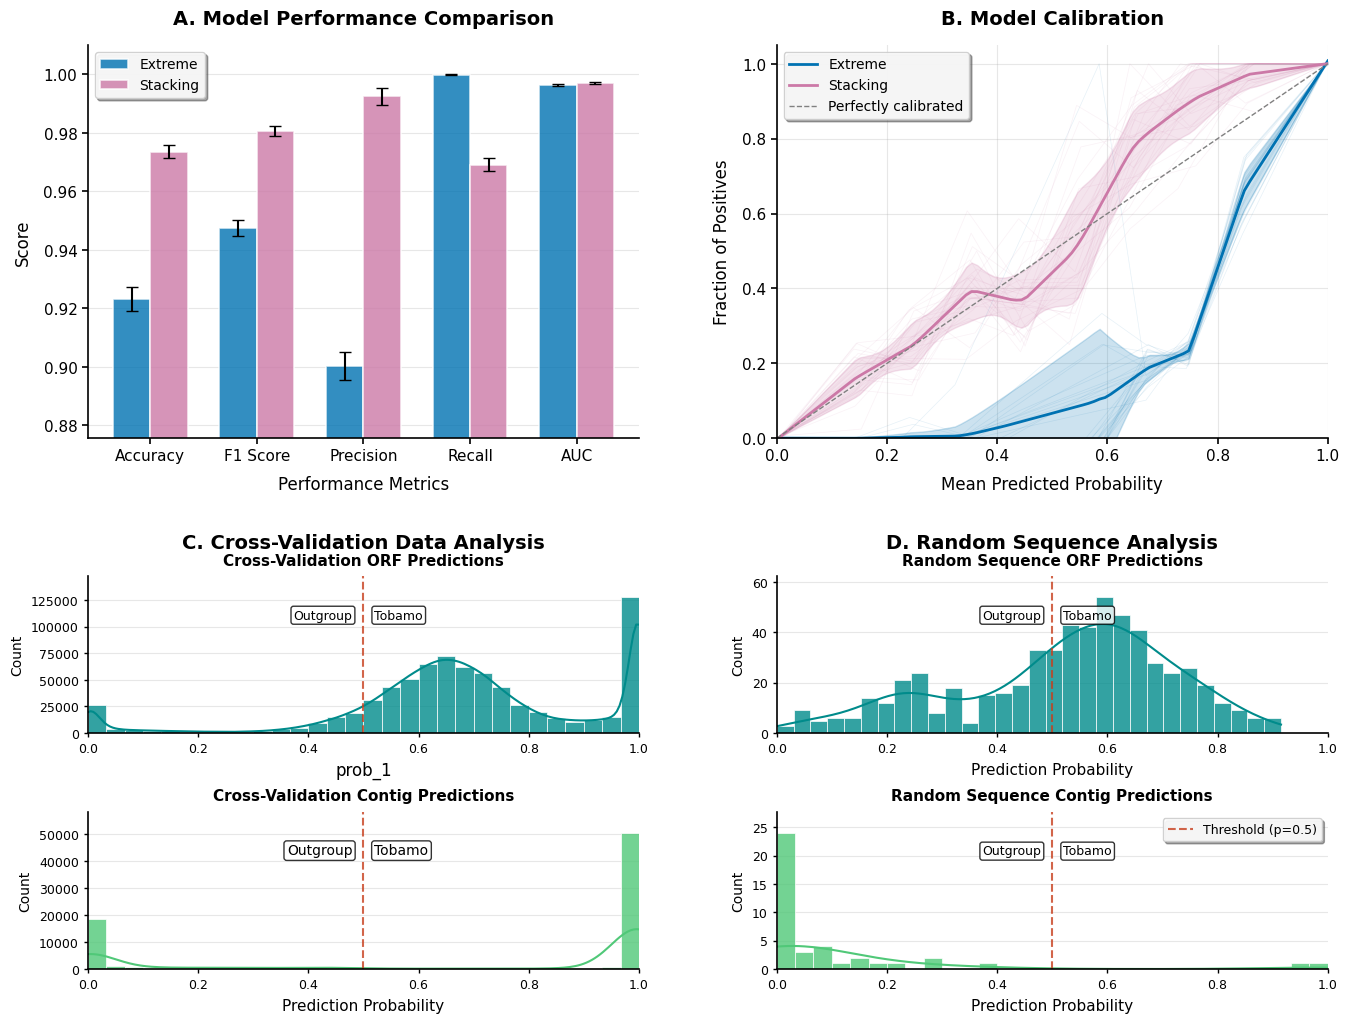

In [4]:
# Publication Ready 2x2 Figure: Model Evaluation and Random Sequence Analysis
# Create a comprehensive figure combining B1 and B2 analyses

# Set up the figure with 2x2 subplots
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

# Use consistent colorblind-friendly colors for A & B panels (method comparison)
colors_ab = ['#0072B2', '#CC79A7']  # Blue and pink for method comparison

# Use different colorblind-friendly colors for C & D panels (data type comparison)
colors_cd = ['#008B8B', '#50C878']  # Teal and Emerald for ORF vs Contig

# Map the actual method names from the data to colors
actual_methods = df_cal['mc_name'].unique()
comparison_methods = method_comparison['method'].values

# Create mapping from comparison methods to actual data methods
method_mapping = {}
for comp_method in comparison_methods:
    if comp_method == 'extreme':
        if 'most_extreme' in actual_methods:
            method_mapping[comp_method] = 'most_extreme'
        elif 'extreme' in actual_methods:
            method_mapping[comp_method] = 'extreme'
    else:
        method_mapping[comp_method] = comp_method

# Create color mapping for both comparison and actual method names (A & B panels)
method_colors = {}
for i, comp_method in enumerate(comparison_methods):
    actual_method = method_mapping.get(comp_method, comp_method)
    method_colors[comp_method] = colors_ab[i]
    method_colors[actual_method] = colors_ab[i]

# B1 Left: Performance Metrics Comparison
ax_b1_metrics = fig.add_subplot(gs[0, 0])

# Extract metrics from comparison DataFrame
metrics = ['accuracy', 'f1', 'precision', 'recall', 'auc']
metric_labels = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'AUC']

# Bar positioning
x = np.arange(len(metrics))
width = 0.35
bar_positions = [x - width/2, x + width/2]

# Plot bars with error bars for each method
for i, comp_method in enumerate(comparison_methods):
    means = [method_comparison.loc[method_comparison['method'] == comp_method, f'{metric}_mean'].iloc[0] for metric in metrics]
    stds = [method_comparison.loc[method_comparison['method'] == comp_method, f'{metric}_std'].iloc[0] for metric in metrics]
    
    display_method = 'stacking' if comp_method == 'histogram' else comp_method
    
    ax_b1_metrics.bar(bar_positions[i], means, width, yerr=stds, capsize=4,
           label=display_method.capitalize(), alpha=0.8, color=method_colors[comp_method], 
           edgecolor='white', linewidth=1.2)

# Formatting for B1 metrics plot
ax_b1_metrics.set_xticks(x)
ax_b1_metrics.set_xticklabels(metric_labels, fontsize=11)
ax_b1_metrics.set_xlabel('Performance Metrics', fontsize=12, labelpad=8)
ax_b1_metrics.set_ylabel('Score', fontsize=12, labelpad=8)

# Set y-axis limits
min_vals = [method_comparison[f'{m}_mean'].min() - method_comparison[f'{m}_std'].max() for m in metrics]
y_min = max(0.85, min(min_vals) - 0.02)
ax_b1_metrics.set_ylim(y_min, 1.01)

# Enhanced grid and styling
ax_b1_metrics.grid(axis='y', linestyle='-', alpha=0.3, linewidth=0.8)
ax_b1_metrics.set_axisbelow(True)
ax_b1_metrics.set_title('A. Model Performance Comparison', fontsize=14, pad=15, weight='bold')

# Legend
legend = ax_b1_metrics.legend(loc='upper left', fontsize=10, frameon=True, 
                             fancybox=True, shadow=True, framealpha=0.9)

# Remove spines
ax_b1_metrics.spines['top'].set_visible(False)
ax_b1_metrics.spines['right'].set_visible(False)
ax_b1_metrics.spines['left'].set_linewidth(1.2)
ax_b1_metrics.spines['bottom'].set_linewidth(1.2)
ax_b1_metrics.tick_params(axis='both', which='major', labelsize=11, width=1.2, length=4)

# B1 Right: Calibration Curves
ax_b1_cal = fig.add_subplot(gs[0, 1])

# Plot calibration curves with confidence intervals for BOTH methods
for i, comp_method in enumerate(comparison_methods):
    actual_method = method_mapping.get(comp_method, comp_method)
    method_data = df_cal[df_cal['mc_name'] == actual_method]
    
    if len(method_data) == 0:
        print(f"Warning: No data found for method '{actual_method}' (mapped from '{comp_method}') in calibration data")
        continue
    
    # Store calibration curves for confidence intervals
    prob_true_values = []
    prob_pred_values = []
    
    iterations = method_data['iteration'].unique() if 'iteration' in method_data.columns else [0]
    
    for iteration in iterations:
        iter_data = method_data[method_data['iteration'] == iteration] if 'iteration' in method_data.columns else method_data
        
        if len(iter_data) > 0:
            y_true = iter_data['ground_truth']
            y_scores = iter_data['prob_1']
            
            if len(y_true) > 10 and len(np.unique(y_true)) > 1:
                prob_true, prob_pred = calibration_curve(y_true, y_scores, n_bins=10)
                ax_b1_cal.plot(prob_pred, prob_true, color=method_colors[comp_method], 
                              alpha=0.1, lw=0.5)
                prob_true_values.append(prob_true)
                prob_pred_values.append(prob_pred)
    
    if prob_true_values:
        x_interp = np.linspace(0, 1, 100)
        interp_curves = []
        for prob_true, prob_pred in zip(prob_true_values, prob_pred_values):
            if len(prob_pred) > 1:
                interp_func = interp1d(prob_pred, prob_true, bounds_error=False, fill_value="extrapolate")
                interp_curves.append(interp_func(x_interp))
        
        if interp_curves:
            interp_array = np.array(interp_curves)
            mean_curve = np.nanmean(interp_array, axis=0)
            std_curve = np.nanstd(interp_array, axis=0)
            
            display_method = 'stacking' if comp_method == 'histogram' else comp_method
            ax_b1_cal.plot(x_interp, mean_curve, color=method_colors[comp_method], 
                          label=f'{display_method.capitalize()}', lw=2)
            ax_b1_cal.fill_between(x_interp, np.maximum(0, mean_curve - std_curve),
                                  np.minimum(1, mean_curve + std_curve), 
                                  color=method_colors[comp_method], alpha=0.2)

# Add reference line and formatting for calibration curve
ax_b1_cal.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1, label='Perfectly calibrated')
ax_b1_cal.set_xlim([0.0, 1.0])
ax_b1_cal.set_ylim([0.0, 1.05])
ax_b1_cal.set_xlabel('Mean Predicted Probability', fontsize=12, labelpad=8)
ax_b1_cal.set_ylabel('Fraction of Positives', fontsize=12, labelpad=8)
ax_b1_cal.set_title('B. Model Calibration', fontsize=14, pad=15, weight='bold')

legend = ax_b1_cal.legend(loc="upper left", fontsize=10, frameon=True, fancybox=True, shadow=True, framealpha=0.9)

ax_b1_cal.grid(True, linestyle='-', alpha=0.3, linewidth=0.8)
ax_b1_cal.set_axisbelow(True)

ax_b1_cal.spines['top'].set_visible(False)
ax_b1_cal.spines['right'].set_visible(False)
ax_b1_cal.spines['left'].set_linewidth(1.2)
ax_b1_cal.spines['bottom'].set_linewidth(1.2)
ax_b1_cal.tick_params(axis='both', which='major', labelsize=11, width=1.2, length=4)

# C. Cross-Validation Data Prediction Analysis (Double subplot)
ax_c = fig.add_subplot(gs[1, 0])

gs_c = ax_c.get_subplotspec().subgridspec(2, 1, hspace=0.5)
ax_c1 = fig.add_subplot(gs_c[0])
ax_c2 = fig.add_subplot(gs_c[1])

# Top: Cross-Validation ORF Predictions
sns.histplot(data=orf_histogram_cv, x="prob_1", bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_c1,
             edgecolor='white', linewidth=0.5)

max_height = ax_c1.get_ylim()[1]
ax_c1.set_ylim(0, max_height * 1.1)
ax_c1.set_title('Cross-Validation ORF Predictions', fontsize=11, pad=8, weight='bold')
ax_c1.set_ylabel('Count', fontsize=10, labelpad=5)
ax_c1.grid(axis='y', linestyle='-', alpha=0.3, linewidth=0.8)
ax_c1.set_axisbelow(True)
ax_c1.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.5, alpha=0.8)
ax_c1.text(0.52, max_height*0.8, "Tobamo", fontsize=9, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
ax_c1.text(0.48, max_height*0.8, "Outgroup", fontsize=9, ha='right', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# Bottom: Cross-Validation Contig Predictions
sns.histplot(data=histogram_cv, x="prob_1", bins=30, kde=True, color=colors_cd[1], alpha=0.8, ax=ax_c2,
             edgecolor='white', linewidth=0.5)

max_height = ax_c2.get_ylim()[1]
ax_c2.set_ylim(0, max_height * 1.1)
ax_c2.set_title('Cross-Validation Contig Predictions', fontsize=11, pad=8, weight='bold')
ax_c2.set_xlabel('Prediction Probability', fontsize=11, labelpad=5)
ax_c2.set_ylabel('Count', fontsize=10, labelpad=5)
ax_c2.grid(axis='y', linestyle='-', alpha=0.3, linewidth=0.8)
ax_c2.set_axisbelow(True)
ax_c2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.5, alpha=0.8)
ax_c2.text(0.52, max_height*0.8, "Tobamo", fontsize=10, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
ax_c2.text(0.48, max_height*0.8, "Outgroup", fontsize=10, ha='right', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# Style both C subplots
for ax in [ax_c1, ax_c2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.tick_params(axis='both', which='major', labelsize=9, width=1, length=3)
    ax.set_xlim(0, 1)

ax_c.set_frame_on(False)
ax_c.set_xticks([])
ax_c.set_yticks([])
ax_c.set_title('C. Cross-Validation Data Analysis', fontsize=14, pad=20, weight='bold')

# D. Random Sequence Analysis (Double subplot)
ax_d = fig.add_subplot(gs[1, 1])

gs_d = ax_d.get_subplotspec().subgridspec(2, 1, hspace=0.5)
ax_d1 = fig.add_subplot(gs_d[0])
ax_d2 = fig.add_subplot(gs_d[1])

# Top: Random Sequence ORF Predictions
sns.histplot(data=orf_random_predictions, x="prob_1", bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_d1, 
             edgecolor='white', linewidth=0.5)

max_height = ax_d1.get_ylim()[1]
ax_d1.set_ylim(0, max_height * 1.1)
ax_d1.set_title('Random Sequence ORF Predictions', fontsize=11, pad=8, weight='bold')
ax_d1.set_xlabel('Prediction Probability', fontsize=11, labelpad=5)
ax_d1.set_ylabel('Count', fontsize=10, labelpad=5)
ax_d1.grid(axis='y', linestyle='-', alpha=0.3, linewidth=0.8)
ax_d1.set_axisbelow(True)
ax_d1.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.5, alpha=0.8)
ax_d1.text(0.52, max_height*0.8, "Tobamo", fontsize=9, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
ax_d1.text(0.48, max_height*0.8, "Outgroup", fontsize=9, ha='right', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# Bottom: Random Sequence Contig Predictions
sns.histplot(data=contigs_random_predictions, x="prob_1", bins=30, kde=True, color=colors_cd[1], alpha=0.8, ax=ax_d2,
             edgecolor='white', linewidth=0.5)

max_height = ax_d2.get_ylim()[1]
ax_d2.set_ylim(0, max_height * 1.1)
ax_d2.set_title('Random Sequence Contig Predictions', fontsize=11, pad=8, weight='bold')
ax_d2.set_xlabel('Prediction Probability', fontsize=11, labelpad=5)
ax_d2.set_ylabel('Count', fontsize=10, labelpad=5)
ax_d2.grid(axis='y', linestyle='-', alpha=0.3, linewidth=0.8)
ax_d2.set_axisbelow(True)
threshold_line = ax_d2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.5, alpha=0.8, label='Threshold (p=0.5)')
ax_d2.text(0.52, max_height*0.8, "Tobamo", fontsize=9, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
ax_d2.text(0.48, max_height*0.8, "Outgroup", fontsize=9, ha='right', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

legend = ax_d2.legend(loc='upper right', fontsize=9, frameon=True, fancybox=True, shadow=True, framealpha=0.9)

# Style both D subplots
for ax in [ax_d1, ax_d2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.tick_params(axis='both', which='major', labelsize=9, width=1, length=3)
    ax.set_xlim(0, 1)

ax_d.set_frame_on(False)
ax_d.set_xticks([])
ax_d.set_yticks([])
ax_d.set_title('D. Random Sequence Analysis', fontsize=14, pad=20, weight='bold')

# # Add overall title
# fig.suptitle('Model Evaluation and Random Sequence Analysis', fontsize=18, weight='bold', y=0.95)

# Save the publication figure
# plt.savefig(figures_dir / 'Figure_Publication_Combined_B1_B2.png', dpi=300, bbox_inches='tight', 
#            facecolor='white', edgecolor='none')
# plt.savefig(figures_dir / 'Figure_Publication_Combined_B1_B2.pdf', dpi=300, bbox_inches='tight', 
#            facecolor='white', edgecolor='none')
plt.show()

# print("Publication figure saved as:")
# print(f"  PNG: {figures_dir / 'Figure_Publication_Combined_B1_B2.png'}")
# print(f"  PDF: {figures_dir / 'Figure_Publication_Combined_B1_B2.pdf'}")

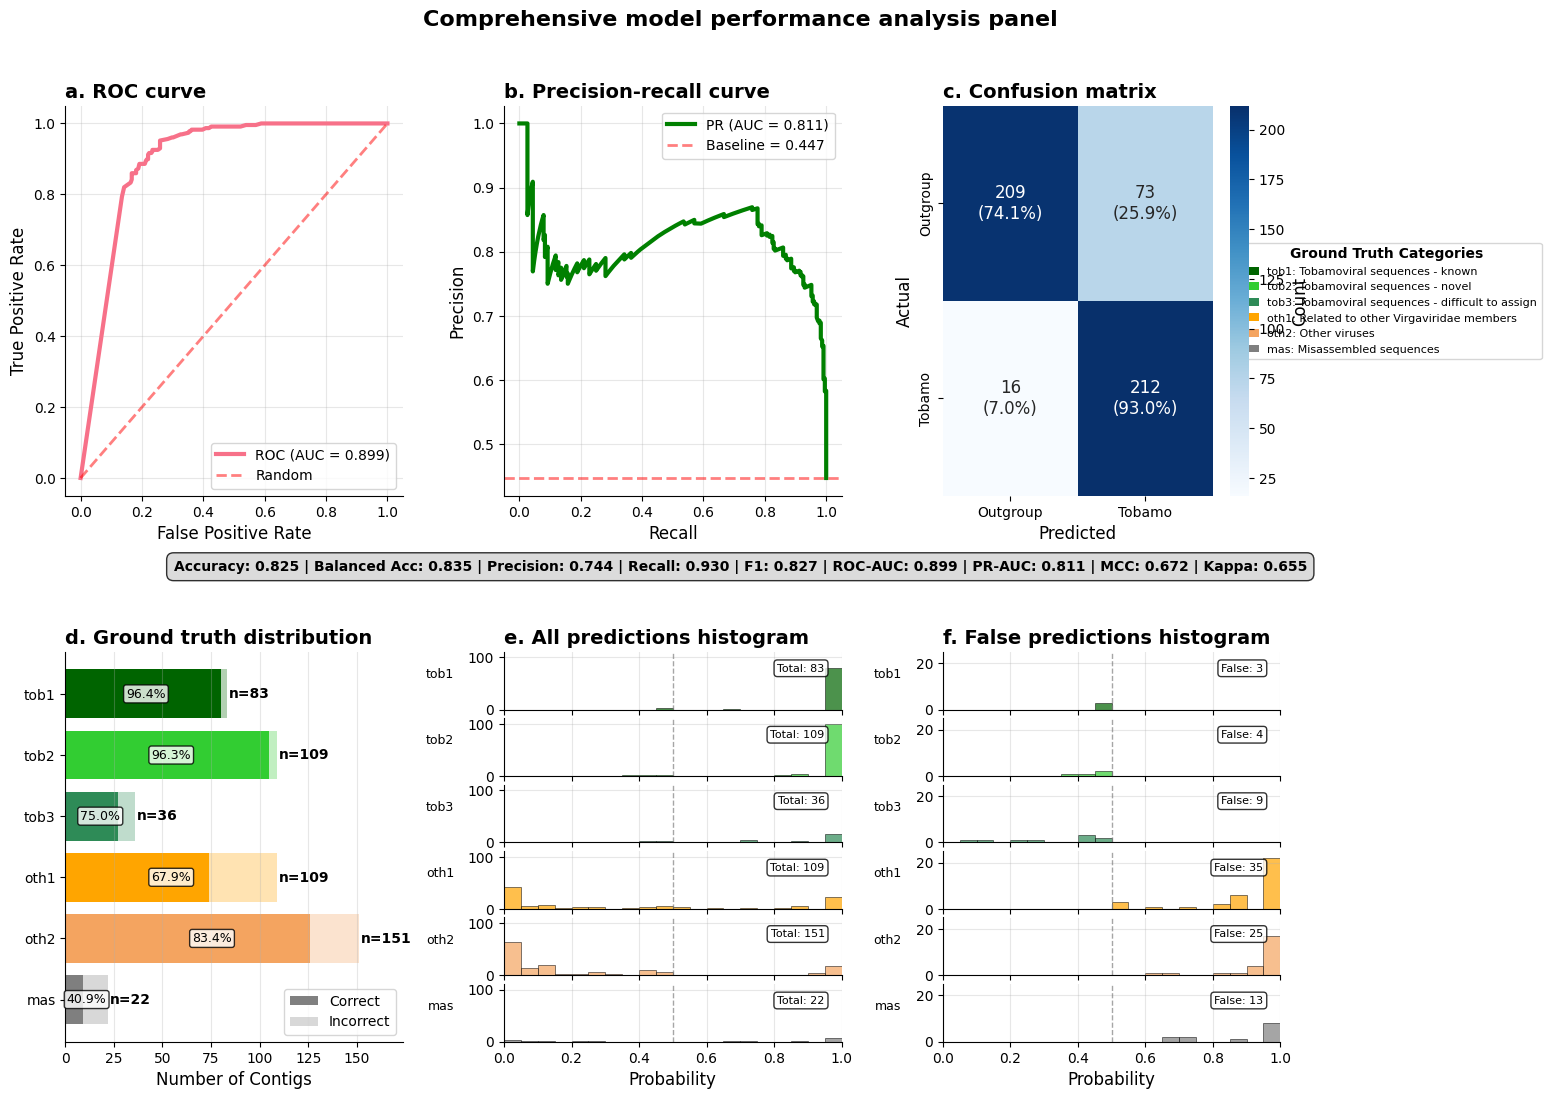

Classification report:
              precision    recall  f1-score   support

    Outgroup       0.93      0.74      0.82       282
      Tobamo       0.74      0.93      0.83       228

    accuracy                           0.83       510
   macro avg       0.84      0.84      0.83       510
weighted avg       0.85      0.83      0.83       510



In [5]:
# COMPREHENSIVE MODEL PERFORMANCE ANALYSIS PANEL
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc as calculate_auc,
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score
    )

# Load ground-truth and prediction data
gt = pd.read_excel('/home/tobamo/analize/project-tobamo/analysis/data/domain_sci_input/ground_truth_final_added_categories.xlsx')
gt.columns = gt.columns.str.strip()

snakemake_predictions_path = '/home/tobamo/analize/project-tobamo/analysis/model/results/snakemake/predictions/contig_predictions.csv'
pr = pd.read_csv(snakemake_predictions_path)

# Merge and prepare data
df = pd.merge(gt, pr, on='contig_name', how='inner').copy()
df['category'] = df['category'].astype(str)
df['prob_1'] = df['prob_1'].astype(float)

# Category configuration
category_palette = {
    'tob1': '#006400',
    'tob2': '#32CD32',
    'tob3': '#2E8B57',
    'oth1': '#FFA500',
    'oth2': '#F4A460',
    'oth3': '#CD853F',
    'mas': '#7F7F7F',
}

category_map = {
    'tob1': 'Tobamoviral sequences - known',
    'tob2': 'Tobamoviral sequences - novel',
    'tob3': 'Tobamoviral sequences - difficult to assign',
    'oth1': 'Related to other Virgaviridae members',
    'oth2': 'Other viruses',
    'oth3': 'Other viruses - difficult to assign',
    'mas': 'Misassembled sequences',
}

# Binary labels
tobamo_categories = ['tob1', 'tob2', 'tob3']
df['gt_binary'] = df['category'].isin(tobamo_categories).astype(int)

# Ensure prediction column exists
if 'predicted_class' not in df.columns:
    df['predicted_class'] = (df['prob_1'] >= 0.5).astype(int)

# Core metrics
y_true = df['gt_binary']
y_pred = df['predicted_class']
y_scores = df['prob_1']

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_scores)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

# Category statistics
custom_order = ['tob1', 'tob2', 'tob3', 'oth1', 'oth2', 'oth3', 'mas']
ordered_labels = [cat for cat in custom_order if cat in df['category'].unique()]

category_stats = []
for cat in ordered_labels:
    cat_data = df[df['category'] == cat]
    cat_count = len(cat_data)
    if cat_count == 0:
        continue
    cat_accuracy = accuracy_score(cat_data['gt_binary'], cat_data['predicted_class'])
    correct_count = int((cat_data['gt_binary'] == cat_data['predicted_class']).sum())
    incorrect_count = cat_count - correct_count
    category_stats.append({
        'category': cat,
        'total_count': cat_count,
        'correct_count': correct_count,
        'incorrect_count': incorrect_count,
        'accuracy': cat_accuracy,
    })
cat_stats_df = pd.DataFrame(category_stats)

# Histogram data
false_predictions = df[df['gt_binary'] != df['predicted_class']].copy()
bin_width = 0.05
bins = np.arange(0, 1 + bin_width, bin_width)

# 2x3 panel
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.4, wspace=0.3)
tick_fontsize = 10
tick_title_fontsize = 12

# a) ROC curve
ax1 = fig.add_subplot(gs[0, 0])
fpr = []
tpr = []
thresholds = np.linspace(0, 1, 101)
for threshold in thresholds:
    pred_thresh = (y_scores >= threshold).astype(int)
    tn, fp_val, fn, tp = confusion_matrix(y_true, pred_thresh).ravel()
    tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr_val = fp_val / (fp_val + tn) if (fp_val + tn) > 0 else 0
    tpr.append(tpr_val)
    fpr.append(fpr_val)
ax1.plot(fpr, tpr, linewidth=3, label=f'ROC (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'r--', alpha=0.5, linewidth=2, label='Random')
ax1.set_title('a. ROC curve', fontsize=14, fontweight='bold', loc='left')
ax1.set_xlabel('False Positive Rate', fontsize=tick_title_fontsize)
ax1.set_ylabel('True Positive Rate', fontsize=tick_title_fontsize)
ax1.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# b) Precision-recall curve
ax2 = fig.add_subplot(gs[0, 1])
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_scores)
pr_auc = calculate_auc(recall_vals, precision_vals)
baseline = y_true.mean()
ax2.plot(recall_vals, precision_vals, 'g-', linewidth=3, label=f'PR (AUC = {pr_auc:.3f})')
ax2.axhline(y=baseline, color='r', linestyle='--', alpha=0.5, linewidth=2, label=f'Baseline = {baseline:.3f}')
ax2.set_title('b. Precision-recall curve', fontsize=14, fontweight='bold', loc='left')
ax2.set_xlabel('Recall', fontsize=tick_title_fontsize)
ax2.set_ylabel('Precision', fontsize=tick_title_fontsize)
ax2.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# c) Confusion matrix
ax3 = fig.add_subplot(gs[0, 2])
cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annotations = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annotations[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)"
sns.heatmap(
    cm,
    annot=annotations,
    fmt='',
    cmap='Blues',
    ax=ax3,
    xticklabels=['Outgroup', 'Tobamo'],
    yticklabels=['Outgroup', 'Tobamo'],
    cbar_kws={'label': 'Count'}
)
ax3.set_title('c. Confusion matrix', fontsize=14, fontweight='bold', loc='left')
ax3.set_xlabel('Predicted', fontsize=tick_title_fontsize)
ax3.set_ylabel('Actual', fontsize=tick_title_fontsize)
ax3.tick_params(axis='both', which='major', labelsize=tick_fontsize)

# d) Ground truth distribution + accuracy
ax4 = fig.add_subplot(gs[1, 0])
y_positions = np.arange(len(cat_stats_df))
for i, (_, row) in enumerate(cat_stats_df.iterrows()):
    ax4.barh(i, row['correct_count'], color=category_palette.get(row['category'], '#999999'), alpha=1.0)
    if row['incorrect_count'] > 0:
        ax4.barh(
            i,
            row['incorrect_count'],
            left=row['correct_count'],
            color=category_palette.get(row['category'], '#999999'),
            alpha=0.3
        )
ax4.set_yticks(y_positions)
ax4.set_yticklabels([row['category'] for _, row in cat_stats_df.iterrows()], rotation=0)
ax4.set_xlabel('Number of Contigs', fontsize=tick_title_fontsize)
ax4.set_title('d. Ground truth distribution', fontsize=14, fontweight='bold', loc='left')
ax4.tick_params(axis='both', which='major', labelsize=tick_fontsize)
for i, (_, row) in enumerate(cat_stats_df.iterrows()):
    ax4.text(row['total_count'] + 1, i, f"n={row['total_count']}", va='center', ha='left', fontweight='bold', fontsize=10)
    ax4.text(
        max(row['total_count'] / 2, 0.5),
        i,
        f"{row['accuracy']:.1%}",
        va='center',
        ha='center',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8)
    )
legend_elements_accuracy = [
    plt.Rectangle((0, 0), 1, 1, facecolor='gray', alpha=1.0, label='Correct'),
    plt.Rectangle((0, 0), 1, 1, facecolor='gray', alpha=0.3, label='Incorrect')
]
ax4.legend(handles=legend_elements_accuracy, loc='lower right', fontsize=10)
ax4.grid(True, axis='x', alpha=0.3)
ax4.invert_yaxis()
ax4.set_xlim(0, cat_stats_df['total_count'].max() * 1.15)

# e/f) Histograms by category
gs_hist_all = gs[1, 1].subgridspec(len(cat_stats_df), 1, hspace=0.15)
gs_hist_false = gs[1, 2].subgridspec(len(cat_stats_df), 1, hspace=0.15)

max_y_all = 1
max_y_false = 1
for category in cat_stats_df['category']:
    counts_all, _ = np.histogram(df[df['category'] == category]['prob_1'], bins=bins)
    counts_false, _ = np.histogram(false_predictions[false_predictions['category'] == category]['prob_1'], bins=bins)
    max_y_all = max(max_y_all, counts_all.max() if len(counts_all) else 1)
    max_y_false = max(max_y_false, counts_false.max() if len(counts_false) else 1)
max_y_all = int(max_y_all * 1.1) + 1
max_y_false = int(max_y_false * 1.1) + 1

for plot_index, (_, cat_row) in enumerate(cat_stats_df.iterrows()):
    category = cat_row['category']
    color = category_palette.get(category, '#999999')

    # e) All predictions
    ax_hist_all = fig.add_subplot(gs_hist_all[plot_index, 0])
    category_data = df[df['category'] == category]
    if len(category_data) > 0:
        ax_hist_all.hist(category_data['prob_1'], bins=bins, alpha=0.7, color=color, edgecolor='black', linewidth=0.5)
        ax_hist_all.text(
            0.95,
            0.80,
            f"Total: {len(category_data)}",
            transform=ax_hist_all.transAxes,
            ha='right',
            va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            fontsize=8
        )
    else:
        ax_hist_all.text(0.5, 0.5, 'No data', transform=ax_hist_all.transAxes, ha='center', va='center', fontsize=9, alpha=0.7)
    ax_hist_all.set_xlim(0, 1)
    ax_hist_all.set_ylim(0, max_y_all)
    ax_hist_all.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, linewidth=1)
    ax_hist_all.set_ylabel(category, fontsize=9, rotation=0, ha='right', labelpad=10)
    ax_hist_all.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax_hist_all.grid(True, alpha=0.3)
    if plot_index == len(cat_stats_df) - 1:
        ax_hist_all.set_xlabel('Probability', fontsize=tick_title_fontsize)
    else:
        ax_hist_all.set_xticklabels([])

    # f) False predictions
    ax_hist_false = fig.add_subplot(gs_hist_false[plot_index, 0])
    category_false_data = false_predictions[false_predictions['category'] == category]
    if len(category_false_data) > 0:
        ax_hist_false.hist(category_false_data['prob_1'], bins=bins, alpha=0.7, color=color, edgecolor='black', linewidth=0.5)
        ax_hist_false.text(
            0.95,
            0.80,
            f"False: {len(category_false_data)}",
            transform=ax_hist_false.transAxes,
            ha='right',
            va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            fontsize=8
        )
    else:
        ax_hist_false.text(
            0.5,
            0.5,
            'No false\npredictions',
            transform=ax_hist_false.transAxes,
            ha='center',
            va='center',
            fontsize=9,
            alpha=0.7
        )
    ax_hist_false.set_xlim(0, 1)
    ax_hist_false.set_ylim(0, max_y_false)
    ax_hist_false.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, linewidth=1)
    ax_hist_false.set_ylabel(category, fontsize=9, rotation=0, ha='right', labelpad=10)
    ax_hist_false.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax_hist_false.grid(True, alpha=0.3)
    if plot_index == len(cat_stats_df) - 1:
        ax_hist_false.set_xlabel('Probability', fontsize=tick_title_fontsize)
    else:
        ax_hist_false.set_xticklabels([])

# Titles for e/f panels
ax5_invisible = fig.add_subplot(gs[1, 1], frameon=False)
ax5_invisible.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
ax5_invisible.set_title('e. All predictions histogram', fontsize=14, fontweight='bold', loc='left')

ax6_invisible = fig.add_subplot(gs[1, 2], frameon=False)
ax6_invisible.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
ax6_invisible.set_title('f. False predictions histogram', fontsize=14, fontweight='bold', loc='left')

# Global title and metrics line
fig.suptitle('Comprehensive model performance analysis panel', fontsize=16, fontweight='bold', y=0.96)
metrics_text = (
    f"Accuracy: {accuracy:.3f} | Balanced Acc: {balanced_acc:.3f} | Precision: {precision:.3f} | "
    f"Recall: {recall:.3f} | F1: {f1:.3f} | ROC-AUC: {roc_auc:.3f} | PR-AUC: {pr_auc:.3f} | "
    f"MCC: {mcc:.3f} | Kappa: {kappa:.3f}"
)
fig.text(
    0.5,
    0.49,
    metrics_text,
    ha='center',
    va='bottom',
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8)
    )

# Category legend (placed next to panel C)
legend_handles = []
for cat in custom_order:
    if cat in df['category'].unique():
        patch = plt.Rectangle((0, 0), 1, 1, fc=category_palette.get(cat, '#999999'))
        legend_handles.append((patch, f"{cat}: {category_map.get(cat, cat)}"))
if legend_handles:
    patches, labels = zip(*legend_handles)
    ax3.legend(
        patches,
        labels,
        loc='center left',
        bbox_to_anchor=(1.05, 0.5),
        title='Ground Truth Categories',
        fontsize=8,
        frameon=True,
        title_fontproperties={'weight': 'bold', 'size': 10}
    )

plt.subplots_adjust(right=0.80, bottom=0.10)
plt.show()

print('Classification report:')
print(classification_report(y_true, y_pred, target_names=['Outgroup', 'Tobamo']))

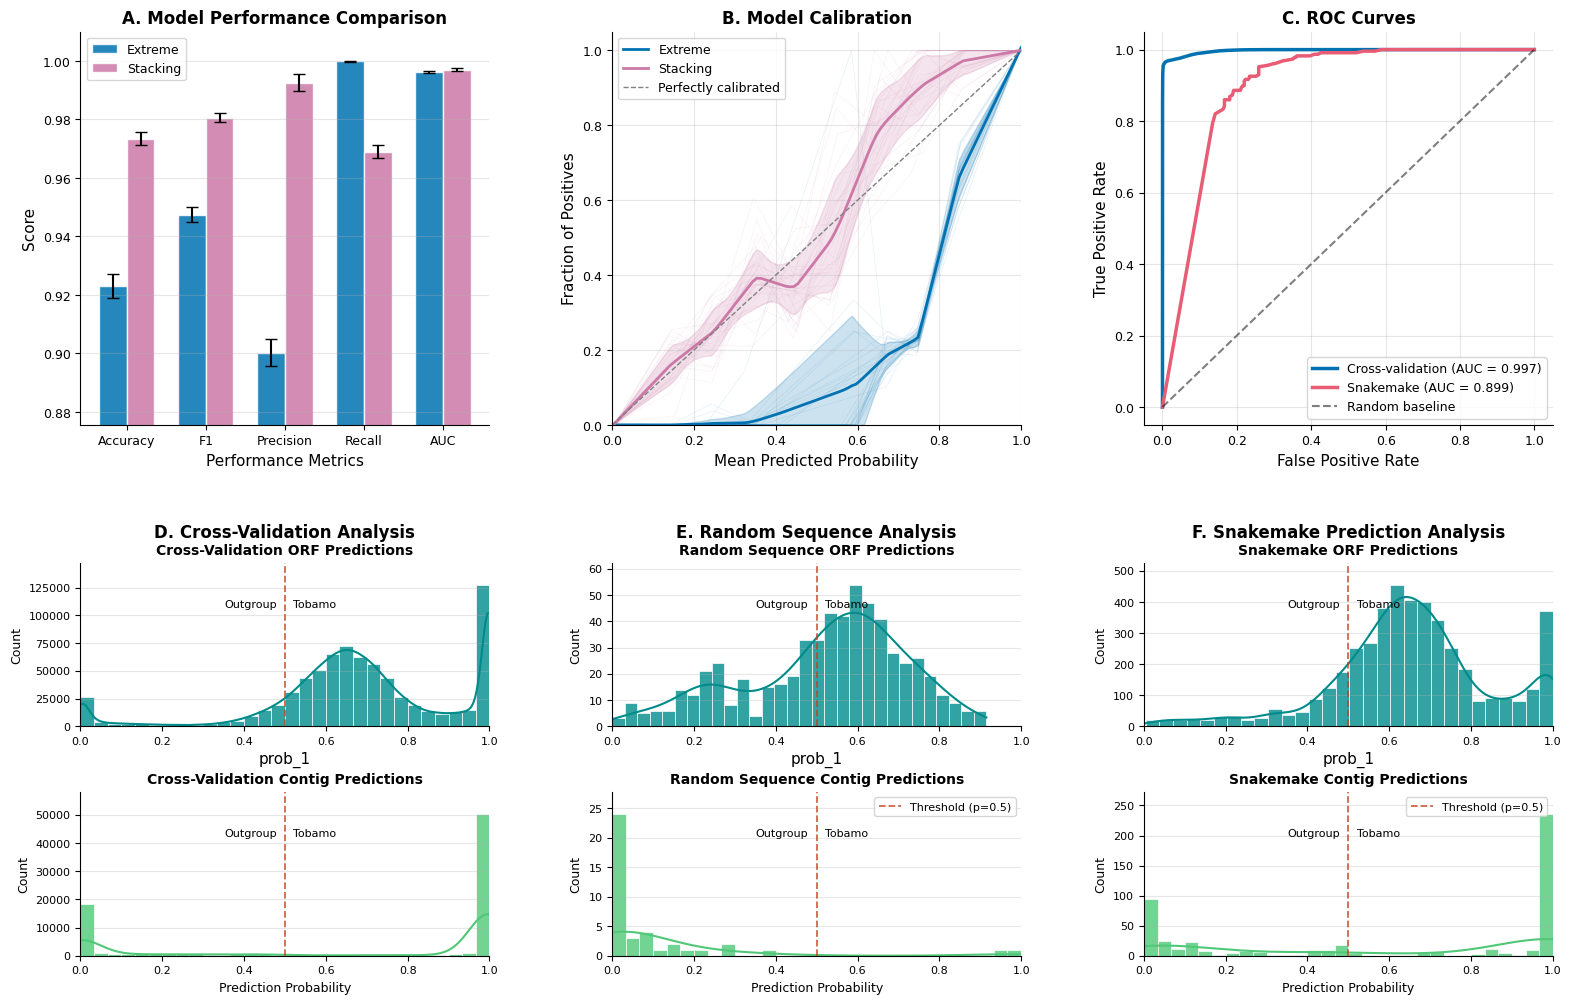

In [13]:
# HYBRID PANEL (SELF-STANDING)
# Row 1: A, B, C
# Row 2: D, E, F
# C contains ROC curves for Cross-Validation + Ground Truth/Snakemake only (no random ROC)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from scipy.interpolate import interp1d

# ------------------------------------------------------------------
# Paths and data loading (self-standing)
# ------------------------------------------------------------------
base_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model')
results_dir = base_dir / 'results'
evaluation_dir = results_dir / 'evaluation_results'

# Evaluation outputs
method_comparison = pd.read_csv(evaluation_dir / 'method_comparison_stats.csv')
extreme_predictions = pd.read_csv(evaluation_dir / 'extreme_predictions_results.csv')
histogram_predictions = pd.read_csv(evaluation_dir / 'histogram_predictions_results.csv')
df_cal = pd.concat([extreme_predictions, histogram_predictions], ignore_index=True)

# Cross-validation hist data
histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results/histogram_predictions_results.csv')
orf_histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results/orf_predictions_results.csv')

# Random-sequence prediction data
orf_random_predictions = pd.read_csv(
    '/home/tobamo/analize/project-tobamo/analysis/model/results/random_seq/predictions/orf_predictions.csv',
    index_col=0
)
contigs_random_predictions = pd.read_csv(
    '/home/tobamo/analize/project-tobamo/analysis/model/results/random_seq/predictions/contig_predictions.csv',
    index_col=0
)

# Snakemake prediction data
snakemake_orf_predictions = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/snakemake/predictions/orf_predictions.csv')
snakemake_contig_predictions = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/snakemake/predictions/contig_predictions.csv')

# Ground truth + snakemake contigs (for GT ROC)
gt = pd.read_excel('/home/tobamo/analize/project-tobamo/analysis/data/domain_sci_input/ground_truth_final_added_categories.xlsx')
gt.columns = gt.columns.str.strip()
df_gt = pd.merge(gt, snakemake_contig_predictions, on='contig_name', how='inner').copy()
df_gt['category'] = df_gt['category'].astype(str)
df_gt['prob_1'] = df_gt['prob_1'].astype(float)
if 'predicted_class' not in df_gt.columns:
    df_gt['predicted_class'] = (df_gt['prob_1'] >= 0.5).astype(int)
tobamo_categories = ['tob1', 'tob2', 'tob3']
df_gt['gt_binary'] = df_gt['category'].isin(tobamo_categories).astype(int)

# ------------------------------------------------------------------
# Shared style/config
# ------------------------------------------------------------------
plt.style.use('default')
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 15,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

colors_ab = ['#0072B2', '#CC79A7']
colors_cd = ['#008B8B', '#50C878']
colors_roc = {'cv': '#0072B2', 'gt': '#E85D75'}

comparison_methods = method_comparison['method'].values
actual_methods = df_cal['mc_name'].unique()

method_mapping = {}
for comp_method in comparison_methods:
    if comp_method == 'extreme':
        if 'most_extreme' in actual_methods:
            method_mapping[comp_method] = 'most_extreme'
        elif 'extreme' in actual_methods:
            method_mapping[comp_method] = 'extreme'
    else:
        method_mapping[comp_method] = comp_method

method_colors = {}
for i, comp_method in enumerate(comparison_methods):
    actual_method = method_mapping.get(comp_method, comp_method)
    method_colors[comp_method] = colors_ab[i]
    method_colors[actual_method] = colors_ab[i]

# ------------------------------------------------------------------
# Figure layout: Row1 A,B,C | Row2 D,E,F
# ------------------------------------------------------------------
fig = plt.figure(figsize=(19, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# A. Performance metrics comparison
ax_a = fig.add_subplot(gs[0, 0])
metrics = ['accuracy', 'f1', 'precision', 'recall', 'auc']
metric_labels = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']
x = np.arange(len(metrics))
width = 0.35
bar_positions = [x - width / 2, x + width / 2]

for i, comp_method in enumerate(comparison_methods):
    means = [method_comparison.loc[method_comparison['method'] == comp_method, f'{metric}_mean'].iloc[0] for metric in metrics]
    stds = [method_comparison.loc[method_comparison['method'] == comp_method, f'{metric}_std'].iloc[0] for metric in metrics]
    display_method = 'stacking' if comp_method == 'histogram' else comp_method
    ax_a.bar(
        bar_positions[i], means, width, yerr=stds, capsize=4,
        label=display_method.capitalize(), alpha=0.85,
        color=method_colors[comp_method], edgecolor='white', linewidth=1.0
    )

ax_a.set_xticks(x)
ax_a.set_xticklabels(metric_labels)
ax_a.set_xlabel('Performance Metrics')
ax_a.set_ylabel('Score')
min_vals = [method_comparison[f'{m}_mean'].min() - method_comparison[f'{m}_std'].max() for m in metrics]
y_min = max(0.85, min(min_vals) - 0.02)
ax_a.set_ylim(y_min, 1.01)
ax_a.grid(axis='y', alpha=0.3)
ax_a.set_title('A. Model Performance Comparison', fontweight='bold')
ax_a.legend(loc='upper left', frameon=True)

# B. Model calibration
ax_b = fig.add_subplot(gs[0, 1])
for i, comp_method in enumerate(comparison_methods):
    actual_method = method_mapping.get(comp_method, comp_method)
    method_data = df_cal[df_cal['mc_name'] == actual_method]
    if len(method_data) == 0:
        continue

    prob_true_values = []
    prob_pred_values = []
    iterations = method_data['iteration'].unique() if 'iteration' in method_data.columns else [0]

    for iteration in iterations:
        iter_data = method_data[method_data['iteration'] == iteration] if 'iteration' in method_data.columns else method_data
        if len(iter_data) == 0:
            continue

        y_true = iter_data['ground_truth']
        y_scores = iter_data['prob_1']
        if len(y_true) > 10 and len(np.unique(y_true)) > 1:
            prob_true, prob_pred = calibration_curve(y_true, y_scores, n_bins=10)
            ax_b.plot(prob_pred, prob_true, color=method_colors[comp_method], alpha=0.1, lw=0.5)
            prob_true_values.append(prob_true)
            prob_pred_values.append(prob_pred)

    if prob_true_values:
        x_interp = np.linspace(0, 1, 100)
        interp_curves = []
        for prob_true, prob_pred in zip(prob_true_values, prob_pred_values):
            if len(prob_pred) > 1:
                interp_func = interp1d(prob_pred, prob_true, bounds_error=False, fill_value='extrapolate')
                interp_curves.append(interp_func(x_interp))

        if interp_curves:
            interp_array = np.array(interp_curves)
            mean_curve = np.nanmean(interp_array, axis=0)
            std_curve = np.nanstd(interp_array, axis=0)
            display_method = 'stacking' if comp_method == 'histogram' else comp_method
            ax_b.plot(x_interp, mean_curve, color=method_colors[comp_method], lw=2, label=display_method.capitalize())
            ax_b.fill_between(
                x_interp,
                np.maximum(0, mean_curve - std_curve),
                np.minimum(1, mean_curve + std_curve),
                color=method_colors[comp_method],
                alpha=0.2,
            )

ax_b.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Perfectly calibrated')
ax_b.set_xlim(0, 1)
ax_b.set_ylim(0, 1.05)
ax_b.set_xlabel('Mean Predicted Probability')
ax_b.set_ylabel('Fraction of Positives')
ax_b.grid(True, alpha=0.3)
ax_b.set_title('B. Model Calibration', fontweight='bold')
ax_b.legend(loc='upper left', frameon=True)

# C. ROC curves (Cross-Validation + Ground Truth/Snakemake)
ax_c = fig.add_subplot(gs[0, 2])

# Cross-validation ROC
y_true_cv = histogram_cv['ground_truth'].astype(int)
y_scores_cv = histogram_cv['prob_1'].astype(float)
auc_cv = roc_auc_score(y_true_cv, y_scores_cv)
thresholds = np.linspace(0, 1, 101)
fpr_cv, tpr_cv = [], []
for threshold in thresholds:
    pred_thresh = (y_scores_cv >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_cv, pred_thresh).ravel()
    fpr_cv.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    tpr_cv.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

# Ground-truth/snakemake ROC
y_true_gt = df_gt['gt_binary'].astype(int)
y_scores_gt = df_gt['prob_1'].astype(float)
auc_gt = roc_auc_score(y_true_gt, y_scores_gt)
fpr_gt, tpr_gt = [], []
for threshold in thresholds:
    pred_thresh = (y_scores_gt >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_gt, pred_thresh).ravel()
    fpr_gt.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    tpr_gt.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

ax_c.plot(fpr_cv, tpr_cv, linewidth=2.5, color=colors_roc['cv'], label=f'Cross-validation (AUC = {auc_cv:.3f})')
ax_c.plot(fpr_gt, tpr_gt, linewidth=2.5, color=colors_roc['gt'], label=f'Snakemake (AUC = {auc_gt:.3f})')
ax_c.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random baseline')
ax_c.set_xlabel('False Positive Rate')
ax_c.set_ylabel('True Positive Rate')
ax_c.set_title('C. ROC Curves', fontweight='bold')
ax_c.grid(True, alpha=0.3)
ax_c.legend(loc='lower right', frameon=True)

# D. Cross-validation predictions (ORF + Contig)
ax_d = fig.add_subplot(gs[1, 0])
gs_d = ax_d.get_subplotspec().subgridspec(2, 1, hspace=0.4)
ax_d1 = fig.add_subplot(gs_d[0])
ax_d2 = fig.add_subplot(gs_d[1])

sns.histplot(data=orf_histogram_cv, x='prob_1', bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_d1, edgecolor='white', linewidth=0.5)
max_height = ax_d1.get_ylim()[1]
ax_d1.set_ylim(0, max_height * 1.1)
ax_d1.set_title('Cross-Validation ORF Predictions', fontsize=10, fontweight='bold')
ax_d1.set_ylabel('Count', fontsize=9)
ax_d1.grid(axis='y', alpha=0.3)
ax_d1.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8)
ax_d1.text(0.52, max_height * 0.8, 'Tobamo', fontsize=8)
ax_d1.text(0.48, max_height * 0.8, 'Outgroup', fontsize=8, ha='right')

sns.histplot(data=histogram_cv, x='prob_1', bins=30, kde=True, color=colors_cd[1], alpha=0.8, ax=ax_d2, edgecolor='white', linewidth=0.5)
max_height = ax_d2.get_ylim()[1]
ax_d2.set_ylim(0, max_height * 1.1)
ax_d2.set_title('Cross-Validation Contig Predictions', fontsize=10, fontweight='bold')
ax_d2.set_xlabel('Prediction Probability', fontsize=9)
ax_d2.set_ylabel('Count', fontsize=9)
ax_d2.grid(axis='y', alpha=0.3)
ax_d2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8)
ax_d2.text(0.52, max_height * 0.8, 'Tobamo', fontsize=8)
ax_d2.text(0.48, max_height * 0.8, 'Outgroup', fontsize=8, ha='right')

for ax in [ax_d1, ax_d2]:
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=8)

ax_d.set_frame_on(False)
ax_d.set_xticks([])
ax_d.set_yticks([])
ax_d.set_title('D. Cross-Validation Analysis', fontsize=12, pad=18, fontweight='bold')

# E. Random-sequence predictions (ORF + Contig)
ax_e = fig.add_subplot(gs[1, 1])
gs_e = ax_e.get_subplotspec().subgridspec(2, 1, hspace=0.4)
ax_e1 = fig.add_subplot(gs_e[0])
ax_e2 = fig.add_subplot(gs_e[1])

sns.histplot(data=orf_random_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_e1, edgecolor='white', linewidth=0.5)
max_height = ax_e1.get_ylim()[1]
ax_e1.set_ylim(0, max_height * 1.1)
ax_e1.set_title('Random Sequence ORF Predictions', fontsize=10, fontweight='bold')
ax_e1.set_ylabel('Count', fontsize=9)
ax_e1.grid(axis='y', alpha=0.3)
ax_e1.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8)
ax_e1.text(0.52, max_height * 0.8, 'Tobamo', fontsize=8)
ax_e1.text(0.48, max_height * 0.8, 'Outgroup', fontsize=8, ha='right')

sns.histplot(data=contigs_random_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[1], alpha=0.8, ax=ax_e2, edgecolor='white', linewidth=0.5)
max_height = ax_e2.get_ylim()[1]
ax_e2.set_ylim(0, max_height * 1.1)
ax_e2.set_title('Random Sequence Contig Predictions', fontsize=10, fontweight='bold')
ax_e2.set_xlabel('Prediction Probability', fontsize=9)
ax_e2.set_ylabel('Count', fontsize=9)
ax_e2.grid(axis='y', alpha=0.3)
ax_e2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8, label='Threshold (p=0.5)')
ax_e2.text(0.52, max_height * 0.8, 'Tobamo', fontsize=8)
ax_e2.text(0.48, max_height * 0.8, 'Outgroup', fontsize=8, ha='right')
ax_e2.legend(loc='upper right', fontsize=8, frameon=True)

for ax in [ax_e1, ax_e2]:
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=8)

ax_e.set_frame_on(False)
ax_e.set_xticks([])
ax_e.set_yticks([])
ax_e.set_title('E. Random Sequence Analysis', fontsize=12, pad=18, fontweight='bold')

# F. Snakemake predictions (ORF + Contig) - mimic D/E style
ax_f = fig.add_subplot(gs[1, 2])
gs_f = ax_f.get_subplotspec().subgridspec(2, 1, hspace=0.4)
ax_f1 = fig.add_subplot(gs_f[0])
ax_f2 = fig.add_subplot(gs_f[1])

sns.histplot(data=snakemake_orf_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_f1, edgecolor='white', linewidth=0.5)
max_height = ax_f1.get_ylim()[1]
ax_f1.set_ylim(0, max_height * 1.1)
ax_f1.set_title('Snakemake ORF Predictions', fontsize=10, fontweight='bold')
ax_f1.set_ylabel('Count', fontsize=9)
ax_f1.grid(axis='y', alpha=0.3)
ax_f1.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8)
ax_f1.text(0.52, max_height * 0.8, 'Tobamo', fontsize=8)
ax_f1.text(0.48, max_height * 0.8, 'Outgroup', fontsize=8, ha='right')

sns.histplot(data=snakemake_contig_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[1], alpha=0.8, ax=ax_f2, edgecolor='white', linewidth=0.5)
max_height = ax_f2.get_ylim()[1]
ax_f2.set_ylim(0, max_height * 1.1)
ax_f2.set_title('Snakemake Contig Predictions', fontsize=10, fontweight='bold')
ax_f2.set_xlabel('Prediction Probability', fontsize=9)
ax_f2.set_ylabel('Count', fontsize=9)
ax_f2.grid(axis='y', alpha=0.3)
ax_f2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8, label='Threshold (p=0.5)')
ax_f2.text(0.52, max_height * 0.8, 'Tobamo', fontsize=8)
ax_f2.text(0.48, max_height * 0.8, 'Outgroup', fontsize=8, ha='right')
ax_f2.legend(loc='upper right', fontsize=8, frameon=True)

for ax in [ax_f1, ax_f2]:
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=8)

ax_f.set_frame_on(False)
ax_f.set_xticks([])
ax_f.set_yticks([])
ax_f.set_title('F. Snakemake Prediction Analysis', fontsize=12, pad=18, fontweight='bold')

# fig.suptitle('Hybrid Model Evaluation Panel', fontsize=16, fontweight='bold', y=0.97)
plt.show()

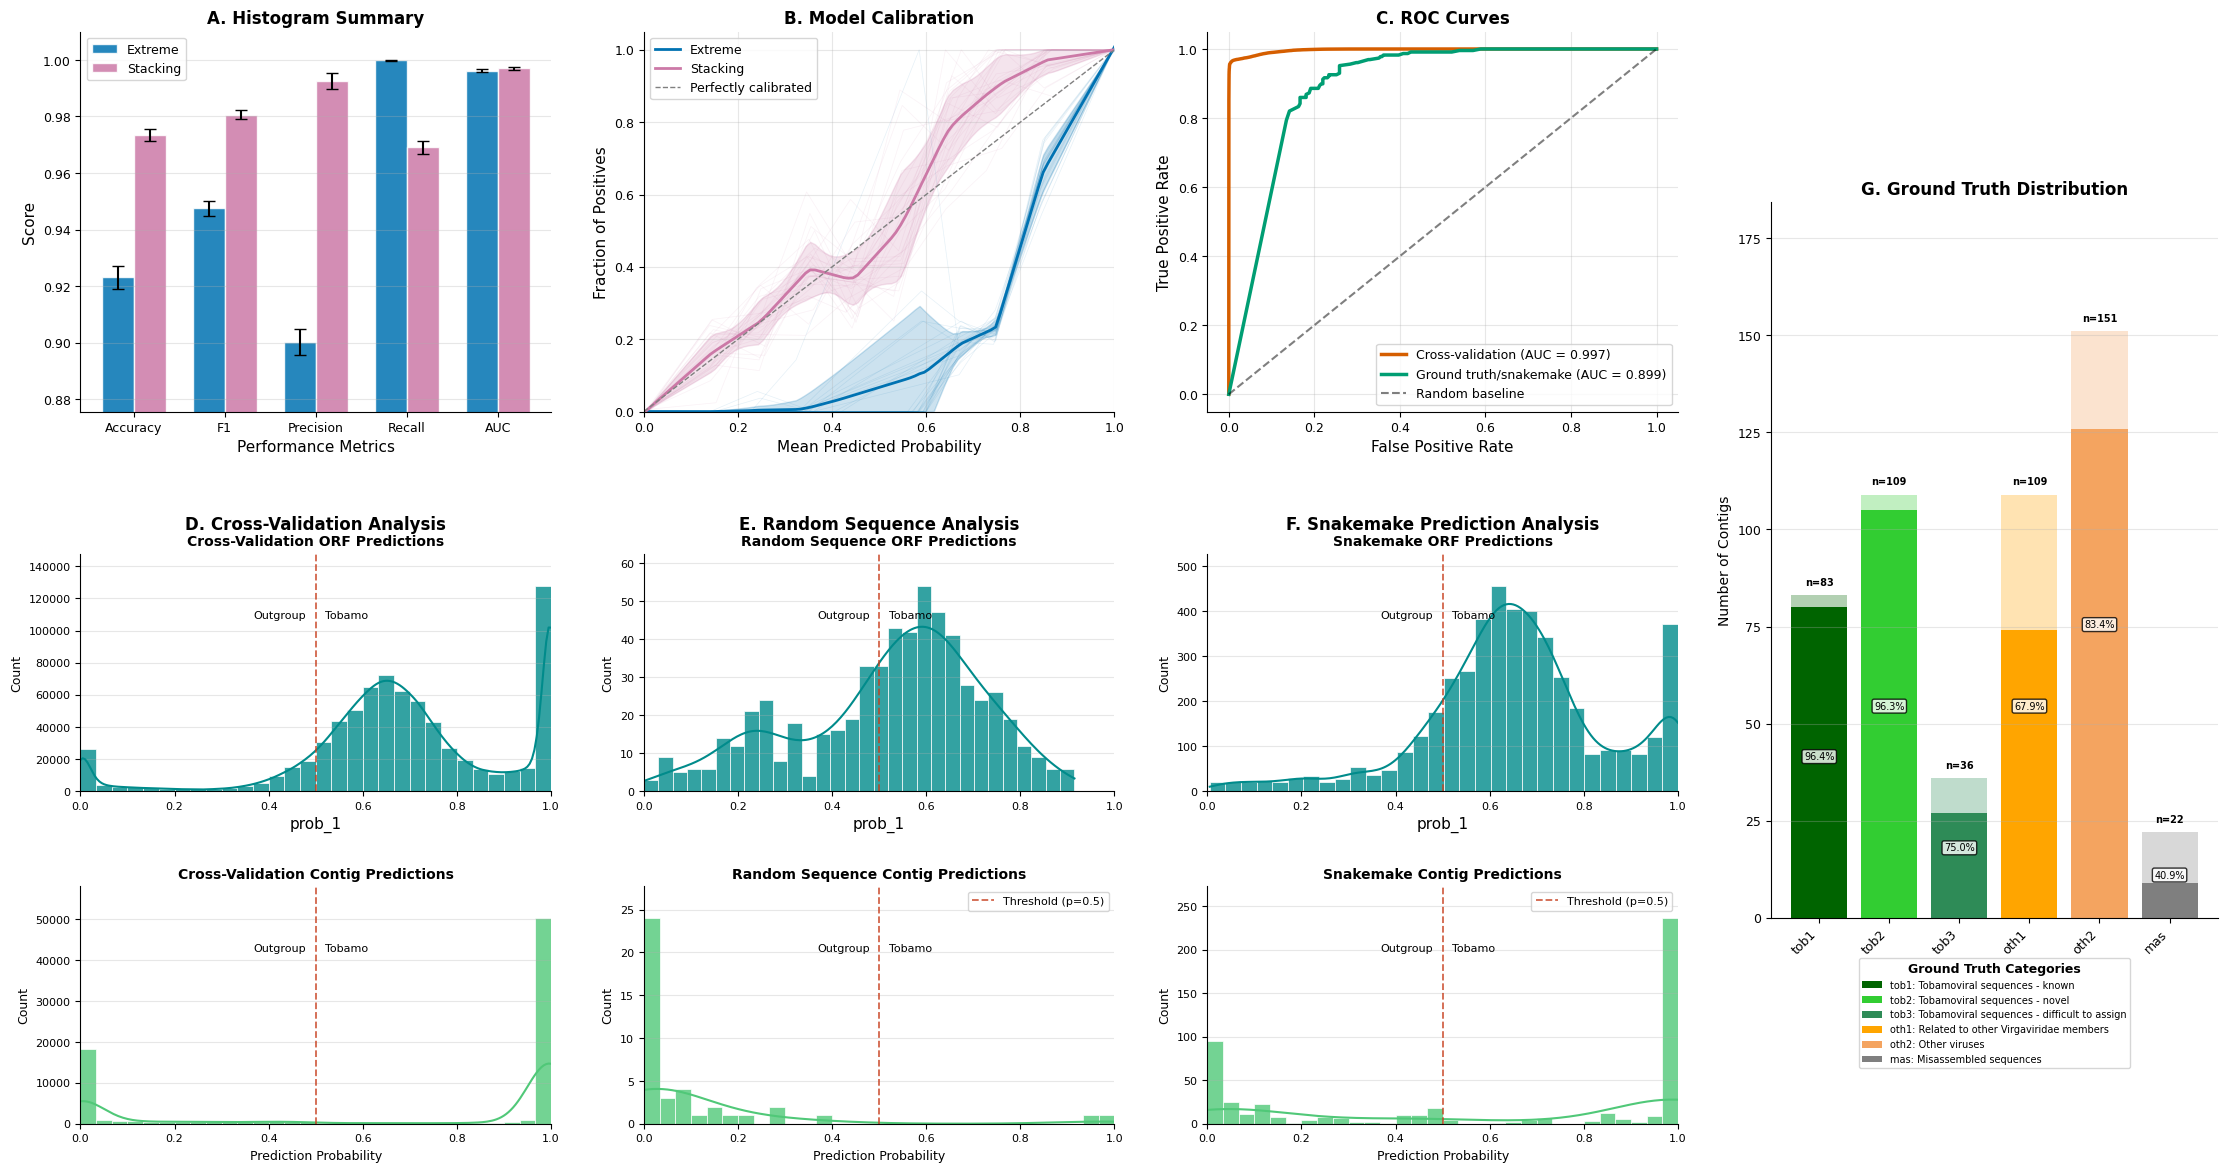

In [7]:
# HYBRID PANEL (SELF-STANDING)
# Main layout:
# Row 1 (left): A Histogram/summary, B Calibration, C ROC
# Row 2 (left): D Cross-validation, E Random, F Snakemake histograms
# Far right: G Ground truth distribution centered vertically, legend below

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, roc_auc_score
from scipy.interpolate import interp1d

# ------------------------------------------------------------------
# Paths and data loading (self-standing)
# ------------------------------------------------------------------
base_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model')
results_dir = base_dir / 'results'
evaluation_dir = results_dir / 'evaluation_results'

# Evaluation outputs
method_comparison = pd.read_csv(evaluation_dir / 'method_comparison_stats.csv')
extreme_predictions = pd.read_csv(evaluation_dir / 'extreme_predictions_results.csv')
histogram_predictions = pd.read_csv(evaluation_dir / 'histogram_predictions_results.csv')
df_cal = pd.concat([extreme_predictions, histogram_predictions], ignore_index=True)

# Cross-validation hist data
histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results/histogram_predictions_results.csv')
orf_histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results/orf_predictions_results.csv')

# Random-sequence prediction data
orf_random_predictions = pd.read_csv(
    '/home/tobamo/analize/project-tobamo/analysis/model/results/random_seq/predictions/orf_predictions.csv',
    index_col=0
)
contigs_random_predictions = pd.read_csv(
    '/home/tobamo/analize/project-tobamo/analysis/model/results/random_seq/predictions/contig_predictions.csv',
    index_col=0
)

# Snakemake prediction data
snakemake_orf_predictions = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/snakemake/predictions/orf_predictions.csv')
snakemake_contig_predictions = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/snakemake/predictions/contig_predictions.csv')

# Ground truth + snakemake contigs (for GT distribution + GT ROC)
gt = pd.read_excel('/home/tobamo/analize/project-tobamo/analysis/data/domain_sci_input/ground_truth_final_added_categories.xlsx')
gt.columns = gt.columns.str.strip()
df_gt = pd.merge(gt, snakemake_contig_predictions, on='contig_name', how='inner').copy()
df_gt['category'] = df_gt['category'].astype(str)
df_gt['prob_1'] = df_gt['prob_1'].astype(float)
if 'predicted_class' not in df_gt.columns:
    df_gt['predicted_class'] = (df_gt['prob_1'] >= 0.5).astype(int)
tobamo_categories = ['tob1', 'tob2', 'tob3']
df_gt['gt_binary'] = df_gt['category'].isin(tobamo_categories).astype(int)

# ------------------------------------------------------------------
# Shared style/config
# ------------------------------------------------------------------
plt.style.use('default')
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 15,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

colors_ab = ['#0072B2', '#CC79A7']
colors_cd = ['#008B8B', '#50C878']
colors_roc = {'cv': '#D55E00', 'gt': '#009E73'}

# Category configuration
category_palette = {
    'tob1': '#006400',
    'tob2': '#32CD32',
    'tob3': '#2E8B57',
    'oth1': '#FFA500',
    'oth2': '#F4A460',
    'oth3': '#CD853F',
    'mas': '#7F7F7F',
}

category_map = {
    'tob1': 'Tobamoviral sequences - known',
    'tob2': 'Tobamoviral sequences - novel',
    'tob3': 'Tobamoviral sequences - difficult to assign',
    'oth1': 'Related to other Virgaviridae members',
    'oth2': 'Other viruses',
    'oth3': 'Other viruses - difficult to assign',
    'mas': 'Misassembled sequences',
}

custom_order = ['tob1', 'tob2', 'tob3', 'oth1', 'oth2', 'oth3', 'mas']

comparison_methods = method_comparison['method'].values
actual_methods = df_cal['mc_name'].unique()

method_mapping = {}
for comp_method in comparison_methods:
    if comp_method == 'extreme':
        if 'most_extreme' in actual_methods:
            method_mapping[comp_method] = 'most_extreme'
        elif 'extreme' in actual_methods:
            method_mapping[comp_method] = 'extreme'
    else:
        method_mapping[comp_method] = comp_method

method_colors = {}
for i, comp_method in enumerate(comparison_methods):
    actual_method = method_mapping.get(comp_method, comp_method)
    method_colors[comp_method] = colors_ab[i]
    method_colors[actual_method] = colors_ab[i]

# Ground truth category stats for panel G
df_gt_panel = df_gt.copy()
df_gt_panel['correct'] = (df_gt_panel['predicted_class'].astype(int) == df_gt_panel['gt_binary'].astype(int)).astype(int)
cat_stats_df = (
    df_gt_panel
    .groupby('category', as_index=False)
    .agg(total_count=('category', 'size'), correct_count=('correct', 'sum'))
)
cat_stats_df['incorrect_count'] = cat_stats_df['total_count'] - cat_stats_df['correct_count']
cat_stats_df['accuracy'] = cat_stats_df['correct_count'] / cat_stats_df['total_count']
cat_stats_df['order'] = cat_stats_df['category'].map({cat: i for i, cat in enumerate(custom_order)}).fillna(999)
cat_stats_df = cat_stats_df.sort_values(['order', 'total_count']).reset_index(drop=True)

# ------------------------------------------------------------------
# Figure layout: 2x3 main + right centered GT panel
# ------------------------------------------------------------------
fig = plt.figure(figsize=(25, 12))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.95], height_ratios=[2, 3], hspace=0.30, wspace=0.20)

# Right-side centered sublayout for Ground Truth panel
gs_right = gs[:, 3].subgridspec(3, 1, height_ratios=[0.45, 2.10, 0.55], hspace=0.0)

# A. Histogram/summary (performance metrics bars)
ax_a = fig.add_subplot(gs[0, 0])
metrics = ['accuracy', 'f1', 'precision', 'recall', 'auc']
metric_labels = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']
x = np.arange(len(metrics))
width = 0.35
bar_positions = [x - width / 2, x + width / 2]

for i, comp_method in enumerate(comparison_methods):
    means = [method_comparison.loc[method_comparison['method'] == comp_method, f'{metric}_mean'].iloc[0] for metric in metrics]
    stds = [method_comparison.loc[method_comparison['method'] == comp_method, f'{metric}_std'].iloc[0] for metric in metrics]
    display_method = 'stacking' if comp_method == 'histogram' else comp_method
    ax_a.bar(
        bar_positions[i], means, width, yerr=stds, capsize=4,
        label=display_method.capitalize(), alpha=0.85,
        color=method_colors[comp_method], edgecolor='white', linewidth=1.0
    )

ax_a.set_xticks(x)
ax_a.set_xticklabels(metric_labels)
ax_a.set_xlabel('Performance Metrics')
ax_a.set_ylabel('Score')
min_vals = [method_comparison[f'{m}_mean'].min() - method_comparison[f'{m}_std'].max() for m in metrics]
y_min = max(0.85, min(min_vals) - 0.02)
ax_a.set_ylim(y_min, 1.01)
ax_a.grid(axis='y', alpha=0.3)
ax_a.set_title('A. Histogram Summary', fontweight='bold')
ax_a.legend(loc='upper left', frameon=True)

# B. Model calibration
ax_b = fig.add_subplot(gs[0, 1])
for i, comp_method in enumerate(comparison_methods):
    actual_method = method_mapping.get(comp_method, comp_method)
    method_data = df_cal[df_cal['mc_name'] == actual_method]
    if len(method_data) == 0:
        continue

    prob_true_values = []
    prob_pred_values = []
    iterations = method_data['iteration'].unique() if 'iteration' in method_data.columns else [0]

    for iteration in iterations:
        iter_data = method_data[method_data['iteration'] == iteration] if 'iteration' in method_data.columns else method_data
        if len(iter_data) == 0:
            continue

        y_true = iter_data['ground_truth']
        y_scores = iter_data['prob_1']
        if len(y_true) > 10 and len(np.unique(y_true)) > 1:
            prob_true, prob_pred = calibration_curve(y_true, y_scores, n_bins=10)
            ax_b.plot(prob_pred, prob_true, color=method_colors[comp_method], alpha=0.1, lw=0.5)
            prob_true_values.append(prob_true)
            prob_pred_values.append(prob_pred)

    if prob_true_values:
        x_interp = np.linspace(0, 1, 100)
        interp_curves = []
        for prob_true, prob_pred in zip(prob_true_values, prob_pred_values):
            if len(prob_pred) > 1:
                interp_func = interp1d(prob_pred, prob_true, bounds_error=False, fill_value='extrapolate')
                interp_curves.append(interp_func(x_interp))

        if interp_curves:
            interp_array = np.array(interp_curves)
            mean_curve = np.nanmean(interp_array, axis=0)
            std_curve = np.nanstd(interp_array, axis=0)
            display_method = 'stacking' if comp_method == 'histogram' else comp_method
            ax_b.plot(x_interp, mean_curve, color=method_colors[comp_method], lw=2, label=display_method.capitalize())
            ax_b.fill_between(
                x_interp,
                np.maximum(0, mean_curve - std_curve),
                np.minimum(1, mean_curve + std_curve),
                color=method_colors[comp_method],
                alpha=0.2,
            )

ax_b.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Perfectly calibrated')
ax_b.set_xlim(0, 1)
ax_b.set_ylim(0, 1.05)
ax_b.set_xlabel('Mean Predicted Probability')
ax_b.set_ylabel('Fraction of Positives')
ax_b.grid(True, alpha=0.3)
ax_b.set_title('B. Model Calibration', fontweight='bold')
ax_b.legend(loc='upper left', frameon=True)

# C. ROC curves (distinct colors)
ax_c = fig.add_subplot(gs[0, 2])

# Cross-validation ROC
y_true_cv = histogram_cv['ground_truth'].astype(int)
y_scores_cv = histogram_cv['prob_1'].astype(float)
auc_cv = roc_auc_score(y_true_cv, y_scores_cv)
thresholds = np.linspace(0, 1, 101)
fpr_cv, tpr_cv = [], []
for threshold in thresholds:
    pred_thresh = (y_scores_cv >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_cv, pred_thresh).ravel()
    fpr_cv.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    tpr_cv.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

# Ground-truth/snakemake ROC
y_true_gt = df_gt['gt_binary'].astype(int)
y_scores_gt = df_gt['prob_1'].astype(float)
auc_gt = roc_auc_score(y_true_gt, y_scores_gt)
fpr_gt, tpr_gt = [], []
for threshold in thresholds:
    pred_thresh = (y_scores_gt >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_gt, pred_thresh).ravel()
    fpr_gt.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    tpr_gt.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

ax_c.plot(fpr_cv, tpr_cv, linewidth=2.5, color=colors_roc['cv'], label=f'Cross-validation (AUC = {auc_cv:.3f})')
ax_c.plot(fpr_gt, tpr_gt, linewidth=2.5, color=colors_roc['gt'], label=f'Ground truth/snakemake (AUC = {auc_gt:.3f})')
ax_c.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random baseline')
ax_c.set_xlabel('False Positive Rate')
ax_c.set_ylabel('True Positive Rate')
ax_c.set_title('C. ROC Curves', fontweight='bold')
ax_c.grid(True, alpha=0.3)
ax_c.legend(loc='lower right', frameon=True)

# D. Cross-validation predictions (ORF + Contig)
ax_d = fig.add_subplot(gs[1, 0])
gs_d = ax_d.get_subplotspec().subgridspec(2, 1, hspace=0.4)
ax_d1 = fig.add_subplot(gs_d[0])
ax_d2 = fig.add_subplot(gs_d[1])

sns.histplot(data=orf_histogram_cv, x='prob_1', bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_d1, edgecolor='white', linewidth=0.5)
max_height = ax_d1.get_ylim()[1]
ax_d1.set_ylim(0, max_height * 1.1)
ax_d1.set_title('Cross-Validation ORF Predictions', fontsize=10, fontweight='bold')
ax_d1.set_ylabel('Count', fontsize=9)
ax_d1.grid(axis='y', alpha=0.3)
ax_d1.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8)
ax_d1.text(0.52, max_height * 0.8, 'Tobamo', fontsize=8)
ax_d1.text(0.48, max_height * 0.8, 'Outgroup', fontsize=8, ha='right')

sns.histplot(data=histogram_cv, x='prob_1', bins=30, kde=True, color=colors_cd[1], alpha=0.8, ax=ax_d2, edgecolor='white', linewidth=0.5)
max_height = ax_d2.get_ylim()[1]
ax_d2.set_ylim(0, max_height * 1.1)
ax_d2.set_title('Cross-Validation Contig Predictions', fontsize=10, fontweight='bold')
ax_d2.set_xlabel('Prediction Probability', fontsize=9)
ax_d2.set_ylabel('Count', fontsize=9)
ax_d2.grid(axis='y', alpha=0.3)
ax_d2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8)
ax_d2.text(0.52, max_height * 0.8, 'Tobamo', fontsize=8)
ax_d2.text(0.48, max_height * 0.8, 'Outgroup', fontsize=8, ha='right')

for ax in [ax_d1, ax_d2]:
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=8)

ax_d.set_frame_on(False)
ax_d.set_xticks([])
ax_d.set_yticks([])
ax_d.set_title('D. Cross-Validation Analysis', fontsize=12, pad=18, fontweight='bold')

# E. Random-sequence predictions (ORF + Contig)
ax_e = fig.add_subplot(gs[1, 1])
gs_e = ax_e.get_subplotspec().subgridspec(2, 1, hspace=0.4)
ax_e1 = fig.add_subplot(gs_e[0])
ax_e2 = fig.add_subplot(gs_e[1])

sns.histplot(data=orf_random_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_e1, edgecolor='white', linewidth=0.5)
max_height = ax_e1.get_ylim()[1]
ax_e1.set_ylim(0, max_height * 1.1)
ax_e1.set_title('Random Sequence ORF Predictions', fontsize=10, fontweight='bold')
ax_e1.set_ylabel('Count', fontsize=9)
ax_e1.grid(axis='y', alpha=0.3)
ax_e1.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8)
ax_e1.text(0.52, max_height * 0.8, 'Tobamo', fontsize=8)
ax_e1.text(0.48, max_height * 0.8, 'Outgroup', fontsize=8, ha='right')

sns.histplot(data=contigs_random_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[1], alpha=0.8, ax=ax_e2, edgecolor='white', linewidth=0.5)
max_height = ax_e2.get_ylim()[1]
ax_e2.set_ylim(0, max_height * 1.1)
ax_e2.set_title('Random Sequence Contig Predictions', fontsize=10, fontweight='bold')
ax_e2.set_xlabel('Prediction Probability', fontsize=9)
ax_e2.set_ylabel('Count', fontsize=9)
ax_e2.grid(axis='y', alpha=0.3)
ax_e2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8, label='Threshold (p=0.5)')
ax_e2.text(0.52, max_height * 0.8, 'Tobamo', fontsize=8)
ax_e2.text(0.48, max_height * 0.8, 'Outgroup', fontsize=8, ha='right')
ax_e2.legend(loc='upper right', fontsize=8, frameon=True)

for ax in [ax_e1, ax_e2]:
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=8)

ax_e.set_frame_on(False)
ax_e.set_xticks([])
ax_e.set_yticks([])
ax_e.set_title('E. Random Sequence Analysis', fontsize=12, pad=18, fontweight='bold')

# F. Snakemake predictions (ORF + Contig)
ax_f = fig.add_subplot(gs[1, 2])
gs_f = ax_f.get_subplotspec().subgridspec(2, 1, hspace=0.4)
ax_f1 = fig.add_subplot(gs_f[0])
ax_f2 = fig.add_subplot(gs_f[1])

sns.histplot(data=snakemake_orf_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_f1, edgecolor='white', linewidth=0.5)
max_height = ax_f1.get_ylim()[1]
ax_f1.set_ylim(0, max_height * 1.1)
ax_f1.set_title('Snakemake ORF Predictions', fontsize=10, fontweight='bold')
ax_f1.set_ylabel('Count', fontsize=9)
ax_f1.grid(axis='y', alpha=0.3)
ax_f1.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8)
ax_f1.text(0.52, max_height * 0.8, 'Tobamo', fontsize=8)
ax_f1.text(0.48, max_height * 0.8, 'Outgroup', fontsize=8, ha='right')

sns.histplot(data=snakemake_contig_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[1], alpha=0.8, ax=ax_f2, edgecolor='white', linewidth=0.5)
max_height = ax_f2.get_ylim()[1]
ax_f2.set_ylim(0, max_height * 1.1)
ax_f2.set_title('Snakemake Contig Predictions', fontsize=10, fontweight='bold')
ax_f2.set_xlabel('Prediction Probability', fontsize=9)
ax_f2.set_ylabel('Count', fontsize=9)
ax_f2.grid(axis='y', alpha=0.3)
ax_f2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8, label='Threshold (p=0.5)')
ax_f2.text(0.52, max_height * 0.8, 'Tobamo', fontsize=8)
ax_f2.text(0.48, max_height * 0.8, 'Outgroup', fontsize=8, ha='right')
ax_f2.legend(loc='upper right', fontsize=8, frameon=True)

for ax in [ax_f1, ax_f2]:
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=8)

ax_f.set_frame_on(False)
ax_f.set_xticks([])
ax_f.set_yticks([])
ax_f.set_title('F. Snakemake Prediction Analysis', fontsize=12, pad=18, fontweight='bold')

# G. Ground truth distribution in far-right middle (transposed, portrait)
ax_g = fig.add_subplot(gs_right[1, 0])
ax_g.set_box_aspect(1.6)

x_positions = np.arange(len(cat_stats_df))
correct_vals = cat_stats_df['correct_count'].values
incorrect_vals = cat_stats_df['incorrect_count'].values
bar_colors = [category_palette.get(cat, '#999999') for cat in cat_stats_df['category']]

ax_g.bar(x_positions, correct_vals, color=bar_colors, alpha=1.0)
ax_g.bar(x_positions, incorrect_vals, bottom=correct_vals, color=bar_colors, alpha=0.3)

ax_g.set_xticks(x_positions)
ax_g.set_xticklabels(cat_stats_df['category'], rotation=45, ha='right')
ax_g.set_ylabel('Number of Contigs', fontsize=10)
ax_g.set_title('G. Ground Truth Distribution', fontsize=12, fontweight='bold')
ax_g.tick_params(axis='both', which='major', labelsize=9)

for i, (_, row) in enumerate(cat_stats_df.iterrows()):
    total = row['total_count']
    ax_g.text(i, total + 2, f"n={total}", ha='center', va='bottom', fontweight='bold', fontsize=7)
    ax_g.text(
        i,
        max(total * 0.5, 0.8),
        f"{row['accuracy']:.1%}",
        va='center',
        ha='center',
        fontsize=7,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8)
    )

if len(cat_stats_df) > 0:
    ax_g.set_ylim(0, cat_stats_df['total_count'].max() * 1.22)
ax_g.grid(True, axis='y', alpha=0.3)

# Category legend under panel G
legend_handles = []
for cat in custom_order:
    if cat in df_gt['category'].unique():
        patch = plt.Rectangle((0, 0), 1, 1, fc=category_palette.get(cat, '#999999'))
        legend_handles.append((patch, f"{cat}: {category_map.get(cat, cat)}"))
if legend_handles:
    patches, labels = zip(*legend_handles)
    ax_g.legend(
        patches,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.05),
        title='Ground Truth Categories',
        fontsize=7,
        ncol=1,
        frameon=True,
        title_fontproperties={'weight': 'bold', 'size': 9}
    )

plt.subplots_adjust(right=0.98, bottom=0.05, top=0.96)
plt.show()

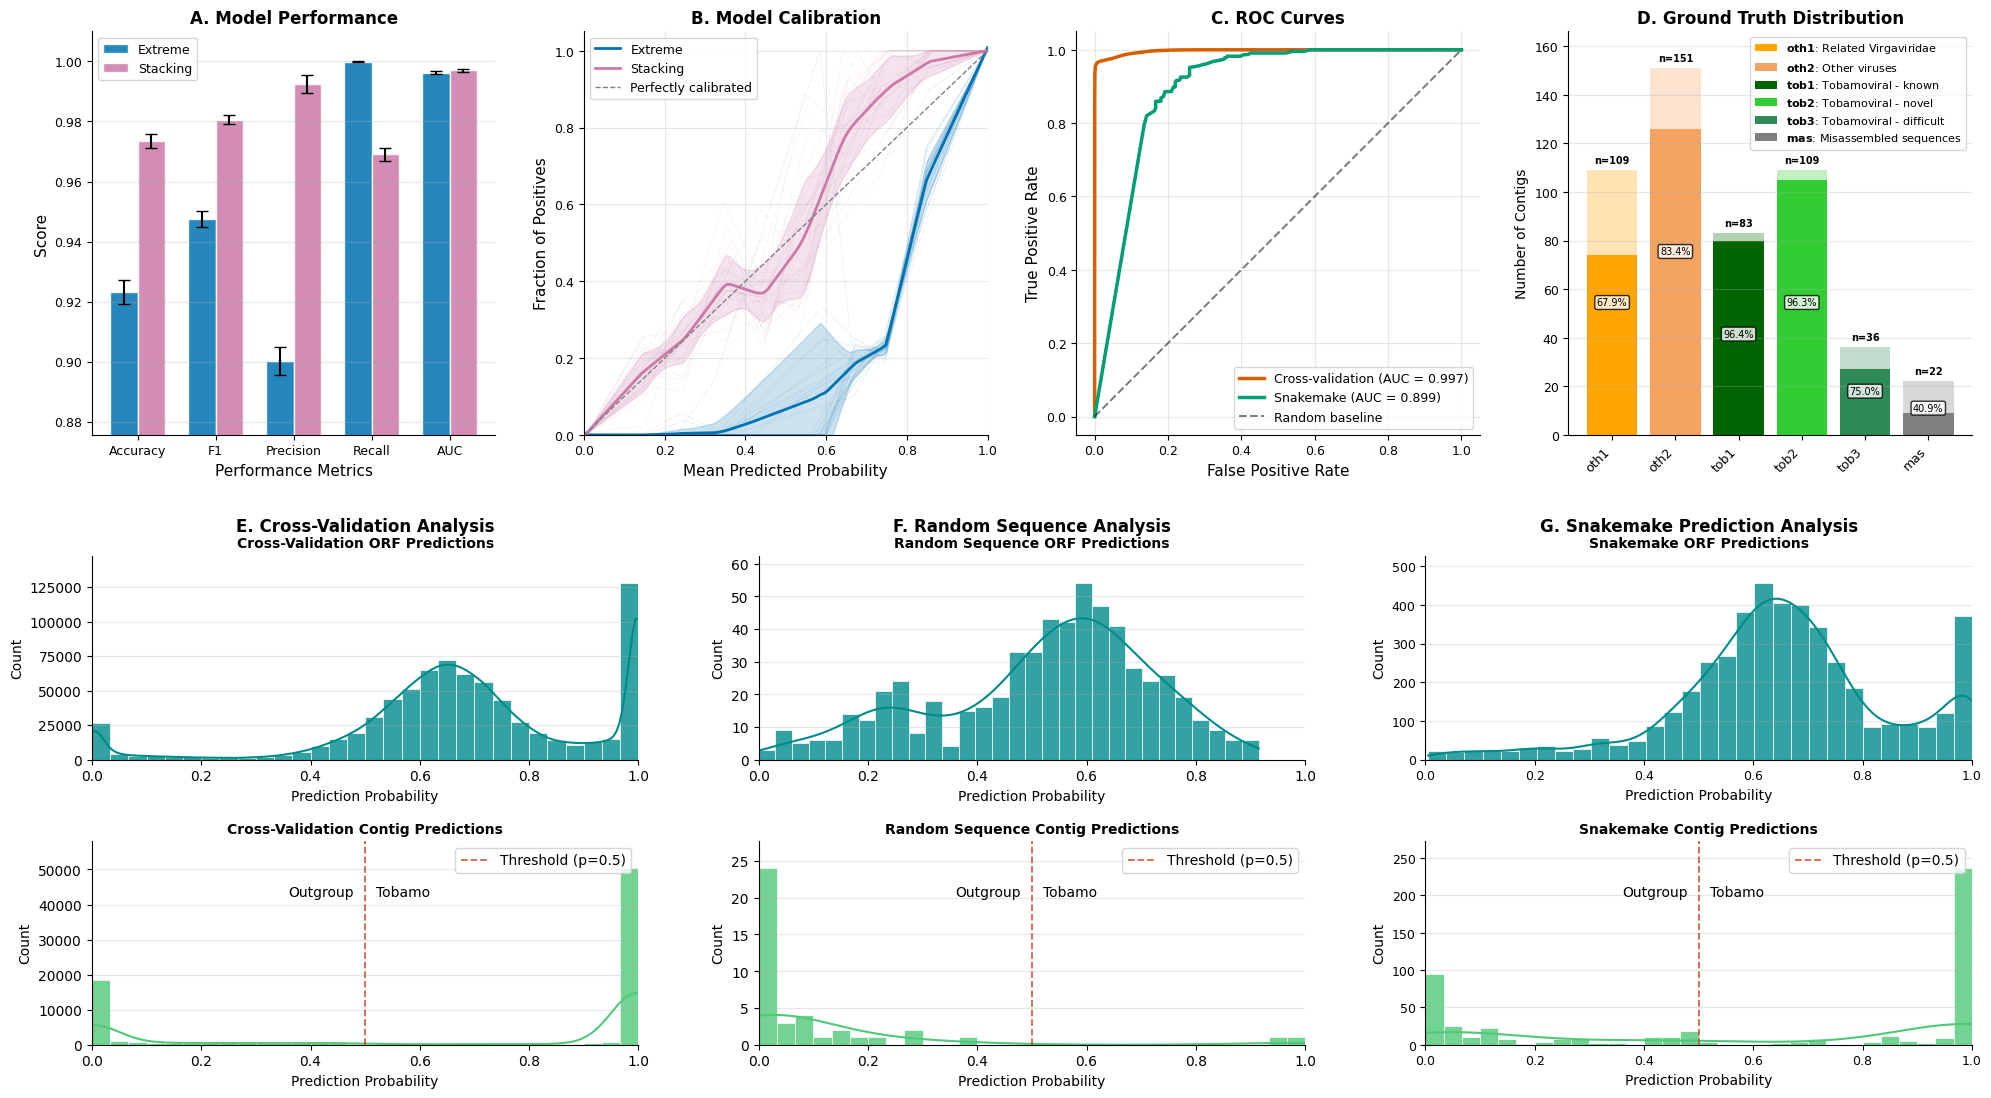

In [17]:
# NEW PANEL (ADDED AT END) - 4-over-3 layout
# Row 1: A model performance, B model calibration, C ROC curves, D Ground truth distribution
# Row 2: E cross-validation, F random sequence, G snakemake prediction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, roc_auc_score
from scipy.interpolate import interp1d

# ------------------------------------------------------------------
# Paths and data loading (self-standing)
# ------------------------------------------------------------------
base_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model')
results_dir = base_dir / 'results'
evaluation_dir = results_dir / 'evaluation_results'

# Evaluation outputs
method_comparison = pd.read_csv(evaluation_dir / 'method_comparison_stats.csv')
extreme_predictions = pd.read_csv(evaluation_dir / 'extreme_predictions_results.csv')
histogram_predictions = pd.read_csv(evaluation_dir / 'histogram_predictions_results.csv')
df_cal = pd.concat([extreme_predictions, histogram_predictions], ignore_index=True)

# Cross-validation hist data
histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results/histogram_predictions_results.csv')
orf_histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results/orf_predictions_results.csv')

# Random-sequence prediction data
orf_random_predictions = pd.read_csv(
    '/home/tobamo/analize/project-tobamo/analysis/model/results/random_seq/predictions/orf_predictions.csv',
    index_col=0
)
contigs_random_predictions = pd.read_csv(
    '/home/tobamo/analize/project-tobamo/analysis/model/results/random_seq/predictions/contig_predictions.csv',
    index_col=0
)

# Snakemake prediction data
snakemake_orf_predictions = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/snakemake/predictions/orf_predictions.csv')
snakemake_contig_predictions = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/snakemake/predictions/contig_predictions.csv')

# Ground truth + snakemake contigs (for GT distribution + GT ROC)
gt = pd.read_excel('/home/tobamo/analize/project-tobamo/analysis/data/domain_sci_input/ground_truth_final_added_categories.xlsx')
gt.columns = gt.columns.str.strip()
df_gt = pd.merge(gt, snakemake_contig_predictions, on='contig_name', how='inner').copy()
df_gt['category'] = df_gt['category'].astype(str)
df_gt['prob_1'] = df_gt['prob_1'].astype(float)
if 'predicted_class' not in df_gt.columns:
    df_gt['predicted_class'] = (df_gt['prob_1'] >= 0.5).astype(int)
tobamo_categories = ['tob1', 'tob2', 'tob3']
df_gt['gt_binary'] = df_gt['category'].isin(tobamo_categories).astype(int)

# ------------------------------------------------------------------
# Shared style/config
# ------------------------------------------------------------------
plt.style.use('default')
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 15,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

colors_ab = ['#0072B2', '#CC79A7']
colors_cd = ['#008B8B', '#50C878']
colors_roc = {'cv': '#D55E00', 'gt': '#009E73'}

category_palette = {
    'tob1': '#006400',
    'tob2': '#32CD32',
    'tob3': '#2E8B57',
    'oth1': '#FFA500',
    'oth2': '#F4A460',
    'oth3': '#CD853F',
    'mas': '#7F7F7F',
}

category_map = {
    'tob1': 'Tobamoviral - known',
    'tob2': 'Tobamoviral - novel',
    'tob3': 'Tobamoviral - difficult',
    'oth1': 'Related Virgaviridae',
    'oth2': 'Other viruses',
    'mas': 'Misassembled sequences',
}

custom_order = ['tob1', 'tob2', 'tob3', 'oth1', 'oth2', 'oth3', 'mas']

comparison_methods = method_comparison['method'].values
actual_methods = df_cal['mc_name'].unique()

method_mapping = {}
for comp_method in comparison_methods:
    if comp_method == 'extreme':
        if 'most_extreme' in actual_methods:
            method_mapping[comp_method] = 'most_extreme'
        elif 'extreme' in actual_methods:
            method_mapping[comp_method] = 'extreme'
    else:
        method_mapping[comp_method] = comp_method

method_colors = {}
for i, comp_method in enumerate(comparison_methods):
    actual_method = method_mapping.get(comp_method, comp_method)
    method_colors[comp_method] = colors_ab[i]
    method_colors[actual_method] = colors_ab[i]

# Ground truth category stats for panel D
df_gt_panel = df_gt.copy()
df_gt_panel['correct'] = (df_gt_panel['predicted_class'].astype(int) == df_gt_panel['gt_binary'].astype(int)).astype(int)
cat_stats_df = (
    df_gt_panel
    .groupby('category', as_index=False)
    .agg(total_count=('category', 'size'), correct_count=('correct', 'sum'))
)
cat_stats_df['incorrect_count'] = cat_stats_df['total_count'] - cat_stats_df['correct_count']
cat_stats_df['accuracy'] = cat_stats_df['correct_count'] / cat_stats_df['total_count']
cat_stats_df['order'] = cat_stats_df['category'].map({cat: i for i, cat in enumerate(custom_order)}).fillna(999)
cat_stats_df = cat_stats_df.sort_values(['order', 'total_count']).reset_index(drop=True)

# ------------------------------------------------------------------
# Figure layout: nested 4-over-3 (tight, non-aligned columns)
# ------------------------------------------------------------------
fig = plt.figure(figsize=(20, 12))
gs_outer = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.16)
gs_top = gs_outer[0].subgridspec(1, 4, width_ratios=[1, 1, 1, 1], wspace=0.22)
gs_bottom = gs_outer[1].subgridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.22)

# A. Model performance
ax_a = fig.add_subplot(gs_top[0, 0])
metrics = ['accuracy', 'f1', 'precision', 'recall', 'auc']
metric_labels = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']
x = np.arange(len(metrics))
width = 0.35
bar_positions = [x - width / 2, x + width / 2]

for i, comp_method in enumerate(comparison_methods):
    means = [method_comparison.loc[method_comparison['method'] == comp_method, f'{metric}_mean'].iloc[0] for metric in metrics]
    stds = [method_comparison.loc[method_comparison['method'] == comp_method, f'{metric}_std'].iloc[0] for metric in metrics]
    display_method = 'stacking' if comp_method == 'histogram' else comp_method
    ax_a.bar(
        bar_positions[i], means, width, yerr=stds, capsize=4,
        label=display_method.capitalize(), alpha=0.85,
        color=method_colors[comp_method], edgecolor='white', linewidth=1.0
    )

ax_a.set_xticks(x)
ax_a.set_xticklabels(metric_labels)
ax_a.set_xlabel('Performance Metrics')
ax_a.set_ylabel('Score')
min_vals = [method_comparison[f'{m}_mean'].min() - method_comparison[f'{m}_std'].max() for m in metrics]
y_min = max(0.85, min(min_vals) - 0.02)
ax_a.set_ylim(y_min, 1.01)
ax_a.grid(axis='y', alpha=0.3)
ax_a.set_title('A. Model Performance', fontweight='bold')
ax_a.legend(loc='upper left', frameon=True)
ax_a.set_box_aspect(1)

# B. Model calibration (square)
ax_b = fig.add_subplot(gs_top[0, 1])
for i, comp_method in enumerate(comparison_methods):
    actual_method = method_mapping.get(comp_method, comp_method)
    method_data = df_cal[df_cal['mc_name'] == actual_method]
    if len(method_data) == 0:
        continue

    prob_true_values = []
    prob_pred_values = []
    iterations = method_data['iteration'].unique() if 'iteration' in method_data.columns else [0]

    for iteration in iterations:
        iter_data = method_data[method_data['iteration'] == iteration] if 'iteration' in method_data.columns else method_data
        if len(iter_data) == 0:
            continue

        y_true = iter_data['ground_truth']
        y_scores = iter_data['prob_1']
        if len(y_true) > 10 and len(np.unique(y_true)) > 1:
            prob_true, prob_pred = calibration_curve(y_true, y_scores, n_bins=10)
            ax_b.plot(prob_pred, prob_true, color=method_colors[comp_method], alpha=0.1, lw=0.5)
            prob_true_values.append(prob_true)
            prob_pred_values.append(prob_pred)

    if prob_true_values:
        x_interp = np.linspace(0, 1, 100)
        interp_curves = []
        for prob_true, prob_pred in zip(prob_true_values, prob_pred_values):
            if len(prob_pred) > 1:
                interp_func = interp1d(prob_pred, prob_true, bounds_error=False, fill_value='extrapolate')
                interp_curves.append(interp_func(x_interp))

        if interp_curves:
            interp_array = np.array(interp_curves)
            mean_curve = np.nanmean(interp_array, axis=0)
            std_curve = np.nanstd(interp_array, axis=0)
            display_method = 'stacking' if comp_method == 'histogram' else comp_method
            ax_b.plot(x_interp, mean_curve, color=method_colors[comp_method], lw=2, label=display_method.capitalize())
            ax_b.fill_between(
                x_interp,
                np.maximum(0, mean_curve - std_curve),
                np.minimum(1, mean_curve + std_curve),
                color=method_colors[comp_method],
                alpha=0.2,
            )

ax_b.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Perfectly calibrated')
ax_b.set_xlim(0, 1)
ax_b.set_ylim(0, 1.05)
ax_b.set_xlabel('Mean Predicted Probability')
ax_b.set_ylabel('Fraction of Positives')
ax_b.grid(True, alpha=0.3)
ax_b.set_title('B. Model Calibration', fontweight='bold')
ax_b.legend(loc='upper left', frameon=True)
ax_b.set_box_aspect(1)

# C. ROC curves (square)
ax_c = fig.add_subplot(gs_top[0, 2])

y_true_cv = histogram_cv['ground_truth'].astype(int)
y_scores_cv = histogram_cv['prob_1'].astype(float)
auc_cv = roc_auc_score(y_true_cv, y_scores_cv)
thresholds = np.linspace(0, 1, 101)
fpr_cv, tpr_cv = [], []
for threshold in thresholds:
    pred_thresh = (y_scores_cv >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_cv, pred_thresh).ravel()
    fpr_cv.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    tpr_cv.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

y_true_gt = df_gt['gt_binary'].astype(int)
y_scores_gt = df_gt['prob_1'].astype(float)
auc_gt = roc_auc_score(y_true_gt, y_scores_gt)
fpr_gt, tpr_gt = [], []
for threshold in thresholds:
    pred_thresh = (y_scores_gt >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_gt, pred_thresh).ravel()
    fpr_gt.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    tpr_gt.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

ax_c.plot(fpr_cv, tpr_cv, linewidth=2.5, color=colors_roc['cv'], label=f'Cross-validation (AUC = {auc_cv:.3f})')
ax_c.plot(fpr_gt, tpr_gt, linewidth=2.5, color=colors_roc['gt'], label=f'Snakemake (AUC = {auc_gt:.3f})')
ax_c.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random baseline')
ax_c.set_xlabel('False Positive Rate')
ax_c.set_ylabel('True Positive Rate')
ax_c.set_title('C. ROC Curves', fontweight='bold')
ax_c.grid(True, alpha=0.3)
ax_c.legend(loc='lower right', frameon=True)
ax_c.set_box_aspect(1)

# D. Ground truth distribution (vertical histogram)
ax_d = fig.add_subplot(gs_top[0, 3])
# ax_d.set_box_aspect(1.6)

panel_d_order = ['oth1', 'oth2', 'tob1', 'tob2', 'tob3', 'mas']
cat_stats_d = cat_stats_df[cat_stats_df['category'].isin(panel_d_order)].copy()
cat_stats_d['plot_order'] = cat_stats_d['category'].map({cat: i for i, cat in enumerate(panel_d_order)})
cat_stats_d = cat_stats_d.sort_values('plot_order').reset_index(drop=True)

x_positions = np.arange(len(cat_stats_d))
correct_vals = cat_stats_d['correct_count'].values
incorrect_vals = cat_stats_d['incorrect_count'].values
bar_colors = [category_palette.get(cat, '#999999') for cat in cat_stats_d['category']]

ax_d.bar(x_positions, correct_vals, color=bar_colors, alpha=1.0)
ax_d.bar(x_positions, incorrect_vals, bottom=correct_vals, color=bar_colors, alpha=0.3)

ax_d.set_xticks(x_positions)
ax_d.set_xticklabels(cat_stats_d['category'], rotation=45, ha='right')
ax_d.set_ylabel('Number of Contigs', fontsize=10)
ax_d.set_title('D. Ground Truth Distribution', fontsize=12, fontweight='bold')
ax_d.tick_params(axis='both', which='major', labelsize=9)
ax_d.set_box_aspect(1)

for i, (_, row) in enumerate(cat_stats_d.iterrows()):
    total = row['total_count']
    ax_d.text(i, total + 2, f"n={total}", ha='center', va='bottom', fontweight='bold', fontsize=7)
    ax_d.text(
        i,
        max(total * 0.5, 0.8),
        f"{row['accuracy']:.1%}",
        va='center',
        ha='center',
        fontsize=7,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8)
    )

if len(cat_stats_d) > 0:
    ax_d.set_ylim(0, cat_stats_d['total_count'].max() * 1.1)
ax_d.grid(True, axis='y', alpha=0.3)

legend_handles = []
for cat in panel_d_order:
    if cat in cat_stats_d['category'].values:
        patch = plt.Rectangle((0, 0), 1, 1, fc=category_palette.get(cat, '#999999'))
        legend_handles.append((patch, rf"$\bf{{{cat}}}$: {category_map.get(cat, cat)}"))
if legend_handles:
    patches, labels = zip(*legend_handles)
    ax_d.legend(
        patches,
        labels,
        loc='upper right',
        # title='Ground Truth Categories',
        fontsize=8,
        ncol=1,
        frameon=True,
        # title_fontproperties={'weight': 'bold', 'size': 8}
    )

# E. Cross-validation
ax_e = fig.add_subplot(gs_bottom[0, 0])
gs_e = ax_e.get_subplotspec().subgridspec(2, 1, hspace=0.4)
ax_e1 = fig.add_subplot(gs_e[0])
ax_e2 = fig.add_subplot(gs_e[1])

sns.histplot(data=orf_histogram_cv, x='prob_1', bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_e1, edgecolor='white', linewidth=0.5)
max_height = ax_e1.get_ylim()[1]
ax_e1.set_ylim(0, max_height * 1.1)
ax_e1.set_title('Cross-Validation ORF Predictions', fontsize=10, fontweight='bold')
ax_e1.set_xlabel('Prediction Probability', fontsize=10)
ax_e1.set_ylabel('Count', fontsize=10)
ax_e1.grid(axis='y', alpha=0.3)

sns.histplot(data=histogram_cv, x='prob_1', bins=30, kde=True, color=colors_cd[1], alpha=0.8, ax=ax_e2, edgecolor='white', linewidth=0.5)
max_height = ax_e2.get_ylim()[1]
ax_e2.set_ylim(0, max_height * 1.1)
ax_e2.set_title('Cross-Validation Contig Predictions', fontsize=10, fontweight='bold')
ax_e2.set_xlabel('Prediction Probability', fontsize=10)
ax_e2.set_ylabel('Count', fontsize=10)
ax_e2.grid(axis='y', alpha=0.3)
ax_e2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8, label='Threshold (p=0.5)')
ax_e2.text(0.52, max_height * 0.8, 'Tobamo', fontsize=10)
ax_e2.text(0.48, max_height * 0.8, 'Outgroup', fontsize=10, ha='right')
ax_e2.legend(loc='upper right', fontsize=10, frameon=True)

for ax in [ax_e1, ax_e2]:
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=10)

ax_e.set_frame_on(False)
ax_e.set_xticks([])
ax_e.set_yticks([])
ax_e.set_title('E. Cross-Validation Analysis', fontsize=12, pad=18, fontweight='bold')

# F. Random sequence
ax_f = fig.add_subplot(gs_bottom[0, 1])
gs_f = ax_f.get_subplotspec().subgridspec(2, 1, hspace=0.4)
ax_f1 = fig.add_subplot(gs_f[0])
ax_f2 = fig.add_subplot(gs_f[1])

sns.histplot(data=orf_random_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_f1, edgecolor='white', linewidth=0.5)
max_height = ax_f1.get_ylim()[1]
ax_f1.set_ylim(0, max_height * 1.1)
ax_f1.set_title('Random Sequence ORF Predictions', fontsize=10, fontweight='bold')
ax_f1.set_ylabel('Count', fontsize=10)
ax_f1.set_xlabel('Prediction Probability', fontsize=10)
ax_f1.grid(axis='y', alpha=0.3)

sns.histplot(data=contigs_random_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[1], alpha=0.8, ax=ax_f2, edgecolor='white', linewidth=0.5)
max_height = ax_f2.get_ylim()[1]
ax_f2.set_ylim(0, max_height * 1.1)
ax_f2.set_title('Random Sequence Contig Predictions', fontsize=10, fontweight='bold')
ax_f2.set_xlabel('Prediction Probability', fontsize=10)
ax_f2.set_ylabel('Count', fontsize=10)
ax_f2.grid(axis='y', alpha=0.3)
ax_f2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8, label='Threshold (p=0.5)')
ax_f2.text(0.52, max_height * 0.8, 'Tobamo', fontsize=10)
ax_f2.text(0.48, max_height * 0.8, 'Outgroup', fontsize=10, ha='right')
ax_f2.legend(loc='upper right', fontsize=10, frameon=True)

for ax in [ax_f1, ax_f2]:
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=10)

ax_f.set_frame_on(False)
ax_f.set_xticks([])
ax_f.set_yticks([])
ax_f.set_title('F. Random Sequence Analysis', fontsize=12, pad=18, fontweight='bold')

# G. Snakemake prediction
ax_g = fig.add_subplot(gs_bottom[0, 2])
gs_g = ax_g.get_subplotspec().subgridspec(2, 1, hspace=0.4)
ax_g1 = fig.add_subplot(gs_g[0])
ax_g2 = fig.add_subplot(gs_g[1])

sns.histplot(data=snakemake_orf_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_g1, edgecolor='white', linewidth=0.5)
max_height = ax_g1.get_ylim()[1]
ax_g1.set_ylim(0, max_height * 1.1)
ax_g1.set_title('Snakemake ORF Predictions', fontsize=10, fontweight='bold')
ax_g1.set_xlabel('Prediction Probability', fontsize=10)
ax_g1.set_ylabel('Count', fontsize=10)
ax_g1.grid(axis='y', alpha=0.3)

sns.histplot(data=snakemake_contig_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[1], alpha=0.8, ax=ax_g2, edgecolor='white', linewidth=0.5)
max_height = ax_g2.get_ylim()[1]
ax_g2.set_ylim(0, max_height * 1.1)
ax_g2.set_title('Snakemake Contig Predictions', fontsize=10, fontweight='bold')
ax_g2.set_xlabel('Prediction Probability', fontsize=10)
ax_g2.set_ylabel('Count', fontsize=10)
ax_g2.grid(axis='y', alpha=0.3)
ax_g2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8, label='Threshold (p=0.5)')
ax_g2.text(0.52, max_height * 0.8, 'Tobamo', fontsize=10)
ax_g2.text(0.48, max_height * 0.8, 'Outgroup', fontsize=10, ha='right')
ax_g2.legend(loc='upper right', fontsize=10, frameon=True)

for ax in [ax_g1, ax_g2]:
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=9)

ax_g.set_frame_on(False)
ax_g.set_xticks([])
ax_g.set_yticks([])
ax_g.set_title('G. Snakemake Prediction Analysis', fontsize=12, pad=18, fontweight='bold')

plt.subplots_adjust(right=0.985, left=0.045, bottom=0.08, top=0.96)

plt.savefig(figures_dir / 'main_fig2.png', dpi=300, bbox_inches='tight', 
           facecolor='white', edgecolor='none')

plt.show()